# 02_bioactivity_enrichment

_Notebook pendiente de desarrollo._

<!-- ÍNDICE DE CELDAS - Paso 2.0 -->
| Celda | Contenido |
|---|---|
| A | Esquema de columnas + tabla_evidencia |
| B | bitacora_exclusiones |
| C | es_puro() |
| D | clasificar_endpoint() |
| E | metodo_obtencion() |
| F | buscar_evidencia_compuesto() |
| G | Prueba con B12 |
| H | Inspección de tabla_evidencia |
| J | reclasificar_tabla_evidencia() |
| K | Diagnóstico bitácora |

In [1]:
%pip install chembl_webresource_client

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from chembl_webresource_client.new_client import new_client

molecule = new_client.molecule
inchikey_caffeic = "QAIPRVGONGVQAS-DUXPYHPUSA-N"

resultado_molecula = molecule.filter(
    molecule_structures__standard_inchi_key=inchikey_caffeic
).only(["molecule_chembl_id", "pref_name"])

lista_molecula = list(resultado_molecula)
print("Resultado de búsqueda por InChIKey:")
print(lista_molecula)

Resultado de búsqueda por InChIKey:
[{'molecule_chembl_id': 'CHEMBL145', 'pref_name': 'CAFFEIC ACID'}]


In [2]:
if lista_molecula:
    mol_id = lista_molecula[0]["molecule_chembl_id"]
    print(f"Molecule ChEMBL ID: {mol_id}\n")

    activity = new_client.activity
    actividades = activity.filter(
        molecule_chembl_id=mol_id
    ).only([
        "target_chembl_id", "target_pref_name", "target_organism",
        "standard_type", "standard_value", "standard_units",
        "assay_type", "assay_description",
        "document_year", "document_journal"
    ])

    lista_actividades = list(actividades[:10])  # solo los primeros 10, para ver rápido
    print(f"Total de actividades encontradas (muestra de 10): {len(lista_actividades)}\n")
    for a in lista_actividades:
        print(a)
        print("---")
else:
    print("⚠️ No se encontró la molécula por InChIKey")

Molecule ChEMBL ID: CHEMBL145

Total de actividades encontradas (muestra de 10): 10

{'assay_description': 'Inhibitory concentration of EGF dependent autophosphorylation of epidermal growth factor receptor kinase', 'assay_type': 'B', 'document_journal': 'J Med Chem', 'document_year': 1989, 'standard_type': 'IC50', 'standard_units': 'nM', 'standard_value': '1200000.0', 'target_chembl_id': 'CHEMBL203', 'target_organism': 'Homo sapiens', 'target_pref_name': 'Epidermal growth factor receptor', 'type': 'IC50', 'units': 'uM', 'value': '1200.0'}
---
{'assay_description': 'Inhibitory concentration of EGF dependent autophosphorylation of epidermal growth factor receptor kinase', 'assay_type': 'B', 'document_journal': 'J Med Chem', 'document_year': 1989, 'standard_type': 'Ki', 'standard_units': 'nM', 'standard_value': '400000.0', 'target_chembl_id': 'CHEMBL203', 'target_organism': 'Homo sapiens', 'target_pref_name': 'Epidermal growth factor receptor', 'type': 'Ki', 'units': 'uM', 'value': '400.0

In [3]:
import requests

respuesta_cellosaurus = requests.get(
    "https://api.cellosaurus.org/search/cell-line",
    params={"q": "MCF-7", "format": "json", "rows": 3}
)

print(f"Código de estado: {respuesta_cellosaurus.status_code}")
print(respuesta_cellosaurus.json())

Código de estado: 200
{'Cellosaurus': {'cell-line-list': [{'accession-list': [{'type': 'primary', 'value': 'CVCL_0031'}], 'age': '69Y', 'category': 'Cancer cell line', 'child-list': [{'accession': {'type': 'primary', 'value': 'CVCL_B8S1'}, 'name': {'type': 'identifier', 'value': 'Abcam MCF-7 ABCC1 KO'}}, {'accession': {'type': 'primary', 'value': 'CVCL_B8S2'}, 'name': {'type': 'identifier', 'value': 'Abcam MCF-7 ABL2 KO'}}, {'accession': {'type': 'primary', 'value': 'CVCL_B8S3'}, 'name': {'type': 'identifier', 'value': 'Abcam MCF-7 ACKR3 KO'}}, {'accession': {'type': 'primary', 'value': 'CVCL_B8S4'}, 'name': {'type': 'identifier', 'value': 'Abcam MCF-7 ACTA2 KO'}}, {'accession': {'type': 'primary', 'value': 'CVCL_B8S5'}, 'name': {'type': 'identifier', 'value': 'Abcam MCF-7 ACVR1B KO'}}, {'accession': {'type': 'primary', 'value': 'CVCL_D2DP'}, 'name': {'type': 'identifier', 'value': 'Abcam MCF-7 ADA KO'}}, {'accession': {'type': 'primary', 'value': 'CVCL_B8S6'}, 'name': {'type': 'identi

In [5]:
molecule_chembl_id_caffeic = "CHEMBL145"
print(f"Trabajando con: {molecule_chembl_id_caffeic} (Caffeic acid)")

Trabajando con: CHEMBL145 (Caffeic acid)


# Paso 2.0 — Mapeo de evidencia biológica existente

*(Subpaso metodológico insertado antes de la selección de target/endpoint,
a partir de una observación del profesor sobre un vacío previo en la metodología)*

## Objetivo

Construir un inventario sistemático de qué evidencia biológica experimental ya existe
—en cualquier modelo biológico y para cualquier tipo de efecto— para cada una de las
37 moléculas del true-positive set (Paso 1), **antes** de decidir en qué target o
endpoint específico concentrar el resto del proyecto.

## Pregunta científica

> Para cada una de las 37 moléculas identificadas en subproductos de caña de azúcar,
> ¿qué se ha probado experimentalmente, en qué sistema biológico, y qué se observó
> —independientemente de si esa evidencia apunta a un target molecular conocido?

## Por qué antes de elegir un target

Elegir un endpoint específico (ej. una línea celular de cáncer) sin antes conocer qué
evidencia ya existe para las 37 moléculas es una decisión arbitraria de conveniencia
técnica, no una decisión informada por los datos. Este subpaso previene tres riesgos:
priorizar un endpoint donde en realidad hay poca evidencia relevante para estas
moléculas específicas; ignorar mecanismos ya reportados que deberían orientar la
elección; y descartar por accidente el tipo de efecto donde estas moléculas sí tienen
trayectoria documentada.

## Decisiones metodológicas confirmadas

**Unidad de análisis: Molécula–Modelo biológico–Endpoint.** Se descartó "molécula"
sola (no captura dónde se probó) y "molécula–modelo" (un mismo modelo puede reportar
endpoints cualitativamente distintos —viabilidad, apoptosis, ROS— que no deben
colapsarse en un registro). Cada fila = una observación única; múltiples estudios
independientes de la misma combinación se permiten como filas adicionales, no se
promedian ni se descartan.

**Alcance: solo compuesto puro/aislado, nunca extracto.** Los 37 compuestos fueron
identificados individualmente por LC-MS/GC-MS en el paper original; aceptar evidencia
de extractos completos introduciría una inconsistencia de nivel de especificidad.
Evidencia encontrada solo a nivel de extracto se registra en bitácora de auditoría,
excluida del mapa final pero no descartada silenciosamente.

**Alcance restringido a los 37 Compound_ID curados en el Paso 1**, sin ampliar por
análogos estructurales. Búsqueda basada en InChIKey (llave validada en el Paso 1),
no en nombre textual.

**Letalidad/efecto:** se conserva siempre el valor experimental original (magnitud +
unidad + categoría de endpoint + nivel biológico), nunca colapsado a una bandera
binaria "letal/no letal" — evita perder la distinción entre citotoxicidad celular,
toxicidad sistémica, apoptosis vs. necrosis.

## Fuentes de datos evaluadas

| Fuente | Acceso | Rol en este subpaso |
|---|---|---|
| ChEMBL | API en vivo (`chembl_webresource_client`) | Fuente primaria — targets, ensayos, actividades |
| Cellosaurus | API en vivo (`api.cellosaurus.org`) | Estandarización de metadatos de línea celular/tejido |
| NPASS | Descarga masiva (sin API de consulta en vivo confirmada) | Candidata secundaria — pendiente de integración |
| BindingDB | Descarga masiva / webservices poco usados | Solo relevante una vez exista target molecular candidato |
| PubMed | Manual | Casos no cubiertos por bases estructuradas |

## Auditoría de factibilidad — validada empíricamente con "Caffeic acid" (CHEMBL145)
como compuesto de referencia neutral (no como elección de endpoint)

| Campo del esquema | Resultado confirmado |
|---|---|
| Nivel_Modelo | ✅ Automatizable directo vía `target.target_type` (valores confirmados: SINGLE PROTEIN, ORGANISM, CELL-LINE, UNCHECKED) |
| Especie / Tejido_Órgano | ✅ Automatizable vía `target.organism` y Cellosaurus `derived-from-site` (ontología UBERON) |
| Categoría_Endpoint / Efecto_Magnitud / Unidad | ✅ Automatizable vía `standard_type` / `standard_value` / `standard_units` |
| Es_Puro | 🟡 Automatizable con regla de **triple verificación** (ver abajo) — un solo campo no basta |
| Tipo_Efecto (dirección) | ❌ No automatizable — `action_type` confirmado sistemáticamente `None` |
| Concentración_Dosis / Tiempo_Exposición | ❌ No automatizable — `activity_properties` confirmado sistemáticamente vacío |
| Mecanismo_Propuesto | ❌ No automatizable para productos naturales — endpoint `mechanism` confirmado vacío |

**Regla de filtrado para Es_Puro** (validada por contraste: 9/10 extractos vegetales
mostraron `molecule_type="Unknown"`, pero 1 excepción —"Scopolia extract"— apareció
como `"Small molecule"`, y se confirmó que extractos sí pueden tener actividad
biológica vinculada en ChEMBL):

# Narrativa completa — Paso 2.0: Mapeo de evidencia biológica de los 37 compuestos

*Este documento reconstruye, en orden, todo el proceso que llevó del true-positive
set del Paso 1 al conjunto de evidencia validado que usamos en el resto del
proyecto — qué se hizo, por qué se hizo en ese orden, qué se encontró en el
camino, y qué limitaciones quedan abiertas. Su propósito es que cualquier
persona (incluido nuestro propio yo futuro) pueda entender no solo el
resultado final, sino la lógica que lo sostiene.*

---

## 1. Origen y objetivo de este subpaso


Es necesario primero caracterizar qué evidencia biológica **ya existe** para
los 37 compuestos del true-positive set — en cualquier modelo, para cualquier
tipo de efecto — evitando así elegir un endpoint a ciegas (como estábamos a
punto de hacer con MCF7, sin ninguna evidencia previa que lo justificara).

**Pregunta que debía responder:** *para cada una de las 37 moléculas
identificadas en subproductos de caña de azúcar, ¿qué se ha probado
experimentalmente, en qué sistema biológico, y qué se observó?*

---

## 2. Flujo de trabajo completo, en el orden en que ocurrió realmente

### Fase 1 — Diseño metodológico (sin tocar código)

Antes de escribir una sola línea, se definieron por escrito:
- **Unidad de análisis:** Molécula–Modelo biológico–Endpoint (no solo molécula,
  ni solo molécula–modelo), para no colapsar efectos cualitativamente distintos
  (viabilidad, apoptosis, ROS) en un solo registro.
- **Criterio de alcance:** solo compuesto puro/aislado, nunca evidencia de
  extractos — consistente con que los 37 compuestos fueron identificados
  individualmente por LC-MS/GC-MS en el paper original.
- **Alcance restringido** a los 37 `Compound_ID` exactos, sin ampliar por
  analogía estructural, usando **InChIKey** (no nombre) como llave de búsqueda.

### Fase 2 — Auditoría de factibilidad, ANTES de comprometerse a un esquema

En vez de asumir qué campos de ChEMBL estarían disponibles, se probó
empíricamente con **un compuesto de referencia neutral: Caffeic acid**
(que resultó ser, coincidencialmente, uno de los propios 37 — B12). Esta
auditoría reveló, antes de escribir el pipeline completo:

| Campo a verificar | Resultado de la prueba |
|---|---|
| `confidence_score` | No vive a nivel de actividad, sino de ensayo; y es estructuralmente bajo (=1) para targets no moleculares como líneas celulares — el propio ChEMBL lo etiqueta como *"Target assigned is non-molecular"* |
| `molecule_type` (para distinguir compuesto puro de extracto) | Funciona como señal fuerte (9/10 extractos de prueba mostraron `"Unknown"`), pero con al menos 1 excepción real (`"Scopolia extract"` con `molecule_type="Small molecule"`) — exige una regla de **triple verificación**, no un solo campo |
| `target_type` (para clasificar el modelo biológico) | Confirmado con valores reales: `SINGLE PROTEIN`, `ORGANISM`, `CELL-LINE`, `UNCHECKED` |

**Por qué esto fue clave:** cada uno de estos hallazgos habría producido un
error silencioso si se hubiera descubierto recién al escalar a los 37
compuestos, en vez de con un solo caso de prueba barato de revisar.

### Fase 3 — Construcción del esquema (22 columnas) y funciones reutilizables

Con la auditoría en mano, se diseñaron y probaron por separado (antes de
integrarlas) tres funciones núcleo:
- `es_puro(nombre, molecule_type, standard_value)` — regla de triple
  verificación (tipo de molécula + ausencia de palabras de mezcla en el nombre
  + valor numérico no nulo).
- `clasificar_endpoint(target_type, organismo, descripción)` — una cascada de
  reglas en orden de especificidad decreciente: primero organismos modelo de
  laboratorio (excluidos de "antimicrobiano"), luego patógenos genuinos, luego
  palabras clave específicas (antioxidante, apoptosis, citotoxicidad...), y
  solo al final un diccionario de respaldo por `target_type` — con un mensaje
  que **se auto-documenta** (`"Sin clasificar (target_type nuevo: X)"`) en vez
  de fallar en silencio ante categorías no previstas.
- `metodo_obtencion(es_puro)` — declara honestamente si una fila es 100%
  automática o tiene campos pendientes de curación manual.

### Fase 4 — Validación con UN compuesto piloto antes de escalar

Se corrió el pipeline completo, de punta a punta, solo para B12 (Caffeic
acid) — no por conveniencia, sino como **prueba de esfuerzo intencional**:
trajo 778 actividades reales, revelando de inmediato patrones (targets tipo
`PROTEIN FAMILY`, organismos de laboratorio, valores de magnitud como texto)
que una muestra más pequeña nunca habría mostrado.

### Fase 5 — Corrección retroactiva del Paso 1 (hallazgo inesperado)

Validando B12, se descubrió que su InChIKey guardado en el Paso 1
(`...UHFFFAOYSA-N`, sin estereoquímica) no coincidía con el InChIKey real y
funcional en ChEMBL (`...DUXPYHPUSA-N`). La causa raíz: la función de consulta
a PubChem del Paso 1 pedía `ConnectivitySMILES` — una representación que
**excluye deliberadamente** toda estereoquímica por diseño de PubChem. Se
re-consultaron automáticamente los 35 compuestos resueltos por API (excluyendo
los 2 ya corregidos manualmente antes), encontrando que **10 de 37** tenían
este defecto: B02, B04, B06, B12, B17, B18, B19, B22, A18, A26. Se verificó
que las 10 correcciones mantuvieran la fórmula molecular exacta antes de
aceptarlas.

### Fase 6 — Escalamiento a los 37 compuestos (el loop completo)

Al correr el ciclo completo sobre los 36 compuestos restantes, aparecieron
problemas que **solo se manifiestan a volumen real**, no en la prueba piloto:

| Problema encontrado | Causa raíz | Corrección aplicada |
|---|---|---|
| Bloqueo indefinido (22+ minutos sin respuesta) | `NEW_CLIENT_TIMEOUT` es `None` por defecto en `chembl_webresource_client` | `Settings.Instance().NEW_CLIENT_TIMEOUT = 30` |
| Filas duplicadas al re-ejecutar un compuesto | La función agregaba (`concat`) sin limpiar filas previas del mismo compuesto | Borrar filas previas de ese `Compound_ID` al inicio de la función (idempotencia) |
| Categorías `PROTEIN FAMILY`, `NO TARGET`, `NON-MOLECULAR` sin clasificar | Solo se habían visto 3 valores de `target_type` en la prueba con 10 actividades; con 778+ aparecieron más | Ampliar el diccionario de respaldo |
| 631 filas de *Rattus norvegicus* / 41 de *Mus musculus* mal etiquetadas como "antimicrobiano" | La regla original asumía "organismo no-humano = patógeno", sin distinguir animales de laboratorio | Lista explícita de organismos modelo, excluidos de esa categoría |
| Suma negativa imposible en verificación de `Es_Puro` | Degradación de tipo `bool`→`int64` tras 25 llamadas sucesivas de `pd.concat()` | Forzar `.astype(bool)` explícitamente |
| 103 filas 100% duplicadas | Concentradas en los compuestos de mayor volumen — consistente con un artefacto de paginación de la API, no con datos reales repetidos | `drop_duplicates()` |
| Error de tipo al calcular potencia (`pX`) | `standard_value` de ChEMBL mezcla texto (`"2300.0"`) y números reales sin aviso | `pd.to_numeric(errors="coerce")` sobre una columna nueva, preservando el dato original |
| IC50 de 323 Molar (concentración físicamente imposible) | Probable valor de relleno de ensayos de cribado masivo poco curados | Filtro de plausibilidad física (0 < pX < 15) |

### Fase 7 — Enriquecimiento con magnitud comparable (pX)

Como los endpoints venían en unidades incompatibles entre sí (nM, %, µg/mL),
se calculó `pX = -log10(concentración molar)` **solo** para los tipos de
endpoint que son genuinamente concentraciones (IC50, EC50, Ki, Kd, GI50) y
con unidad molar reconocida — quedando comparable en **1,029 de 3,663 filas**
(28%); el resto (endpoints como `Inhibition`, `LogP`, valores fisiológicos de
estudios in vivo) queda fuera de esta comparación por no ser la misma
magnitud, no porque el dato en sí sea inválido.

### Fase 8 — Visualización

Se probaron dos enfoques para explorar la asociación origen (melaza/vinaza) →
categoría de efecto: un **chord diagram** construido a mano (sin librerías
externas, con cintas/ribbons en vez de líneas simples, tras dos rondas de
ajuste para evitar superposición de etiquetas), y un **mapa de calor**
(absoluto + normalizado por fila), adoptado como versión final por ser más
preciso y estándar para reporte académico.

---

## 3. Lógica computacional transversal — principios aplicados en todo el proceso

Estos no son reglas de una sola fase — se repitieron una y otra vez, cada vez
que aparecía un problema nuevo:

1. **Probar con un caso antes de escalar a 37** — cada función nueva
   (`es_puro`, `clasificar_endpoint`) se validó primero contra 1-3 casos reales
   conocidos antes de aplicarla en masa.
2. **Nunca confiar en un solo campo sin verificación de contraste** —
   `molecule_type` solo, `confidence_score` solo, o `target_type="ORGANISM"`
   solo, cada uno demostró tener excepciones reales que un segundo criterio
   (nombre, `target_organism`, lista de organismos modelo) permitió detectar.
3. **Materializar resultados de consultas en `list()` inmediatamente** — los
   objetos de `chembl_webresource_client` son perezosos (vuelven a consultar la
   red cada vez que se iteran); no hacerlo causó al menos un error 500 evitable.
4. **Hacer las funciones idempotentes** — cualquier función que escriba sobre
   una tabla compartida debe poder re-ejecutarse sin duplicar, porque los
   reinicios de kernel y las re-ejecuciones accidentales son la norma, no la
   excepción, en un proceso largo.
5. **Fallar de forma visible y auto-documentada, no en silencio** — el mensaje
   `"Sin clasificar (target_type nuevo: X)"` en vez de un genérico `"Otro"` es
   el mismo principio que el filtro `errors="coerce"` de pandas: cuando algo no
   se puede resolver, que quede marcado y trazable, no oculto.

---

## 4. Resultado final (con cifras exactas)

- **37 compuestos** de partida (true-positive set, Paso 1).
- **23 compuestos** con evidencia utilizable en `tabla_evidencia`
  (3,663 filas, tras limpieza de duplicados).
- **2 compuestos** encontrados en ChEMBL sin filas aprovechables (B18:
  `molecule_type` indefinido; A03: cero actividades reportadas).
- **10 compuestos** sin evidencia, confirmada por dos vías independientes
  (InChIKey exacto y búsqueda de respaldo por nombre): B01, B06, B10, B21,
  A05, A07, A19, A22, A25, A29.
- **2 compuestos** con evidencia encontrada solo bajo un isómero distinto
  (B02, A26) — **excluidos** de `tabla_evidencia` por rigor, documentados aparte.
- **1,968 filas** en `bitacora_exclusiones` (mayoritariamente por
  `standard_value` nulo, no por mezclas/extractos — el riesgo de extracto
  queda mayormente prevenido por el propio anclaje en InChIKey).

---

## 5. Limitaciones y posibles sesgos (explícitos, para no sobreinterpretar los hallazgos)

- **Sesgo de publicación:** ausencia de evidencia para un compuesto **no
  implica** ausencia de actividad real — puede simplemente no haberse
  estudiado, o haberse estudiado con resultado negativo nunca publicado. Los
  10 compuestos "vacíos" son un hallazgo sobre la *literatura disponible*, no
  sobre la *química real* de esas moléculas.
- **La clasificación de `Categoria_Endpoint` es heurística, no perfecta** —
  se basa en palabras clave y `target_type`; es posible que algunas filas
  queden en una categoría imprecisa que aún no hemos detectado, especialmente
  en descripciones de ensayo ambiguas o mal escritas en el origen.
- **Cobertura de fuentes incompleta:** solo se consultó ChEMBL (y Cellosaurus
  para metadatos). NPASS y BindingDB fueron evaluados pero no integrados (solo
  ofrecen descarga masiva, no consulta en vivo) — podrían existir estudios
  adicionales, especialmente de productos naturales, no reflejados aquí.
- **ChEMBL tiene sus propios sesgos de curación** — sobre-representa
  compuestos con interés farmacéutico/clínico y ciertos paneles de cribado
  masivo (ej. antimicrobiano, ADMET), lo cual puede inflar esas categorías de
  forma no proporcional al interés biológico real.
- **La comparación de potencia (`pX`) cubre solo el 28% de los datos** — no
  puede extenderse a la mayoría de las filas (`Inhibition`, marcadores
  fisiológicos in vivo, etc.) por ser magnitudes no comparables; cualquier
  conclusión sobre "potencia promedio" aplica solo a ese subconjunto.
- **Tamaños de muestra muy desiguales entre categorías** — algunos promedios
  (ej. una categoría con `n=1`) no son estadísticamente robustos, aunque
  aparezcan en la misma visualización que categorías con cientos de registros.
- **La comparación origen (melaza/vinaza) aún no está normalizada por cantidad
  de compuestos por grupo** — pendiente de cerrar con la Celda TT; hasta
  confirmar esto, la diferencia observada en volumen total no puede
  interpretarse todavía como diferencia de estudio *por compuesto*.
- **La lista de "organismos modelo de laboratorio"** usada para corregir la
  clasificación antimicrobiana es una lista curada manualmente de especies
  comunes — no exhaustiva; podrían existir otros animales de laboratorio menos
  frecuentes aún clasificados incorrectamente como "antimicrobiano".
- **Todas las identificaciones del paper original son "tentativas"** (por
  espectrometría de masas no dirigida) — esta limitación, heredada del Paso 1,
  se propaga a todo lo construido después.

---

## 6. Preguntas que este subpaso deja abiertas para el resto del proyecto

- ¿El patrón "Solo Melaza con casi nula evidencia antioxidante (2.0%)" se
  sostiene al normalizar por compuesto, o es un artefacto de tener pocos
  compuestos exclusivos de melaza en la muestra?
- De los 3 endpoints originalmente propuestos, el antiproliferativo (469
  filas) y el antioxidante (342) tienen más base real que el antiinflamatorio
  (~30) — ¿esto debe pesar en la decisión final de hacia dónde dirigir el
  Entregable 2?
- Los 10 compuestos sin evidencia directa son, por diseño, los candidatos
  naturales para el enfoque de predicción por similitud estructural (Pasos 3-4)
  — ¿tiene sentido priorizarlos explícitamente ahí, dado que aquí no se pudo
  decir nada sobre ellos?

In [4]:
import pandas as pd

In [5]:
#COLUMNAS_ESQUEMA + tabla_evidencia (CELDA A)
COLUMNAS_ESQUEMA = [
    # Identificación (heredado del Paso 1)
    "Compound_ID", "InChIKey", "Name",
    "Molecule_ChEMBL_ID",
    # Modelo biológico
    "Nivel_Modelo", "Modelo_Detalle", "Especie", "Tejido_Organo",
    # Ensayo
    "Tipo_Ensayo",
    # Endpoint y efecto
    "Categoria_Endpoint", "Endpoint_Original", "Efecto_Magnitud", "Efecto_Unidad",
    # Filtro de pureza
    "Es_Puro",
    # Campos confirmados como no automatizables (quedan vacíos salvo curación manual)
    "Tipo_Efecto_Direccion", "Concentracion_Dosis", "Tiempo_Exposicion",
    # Mecanismo/target
    "Target_Conocido", "Mecanismo_Propuesto",
    # Trazabilidad
    "Ensayo_ChEMBL_ID", "Referencia_Bibliografica",
    # Metadato de proceso
    "Metodo_Obtencion",
]

# Verificación de que el esquema no tenga columnas duplicadas por accidente
assert len(COLUMNAS_ESQUEMA) == len(set(COLUMNAS_ESQUEMA)), "❌ Hay columnas duplicadas en el esquema"

tabla_evidencia = pd.DataFrame(columns=COLUMNAS_ESQUEMA)

print(f"✅ Esquema maestro creado con {len(COLUMNAS_ESQUEMA)} columnas")
tabla_evidencia

✅ Esquema maestro creado con 22 columnas


,Compound_ID,InChIKey,Name,Molecule_ChEMBL_ID,Nivel_Modelo,Modelo_Detalle,Especie,Tejido_Organo,Tipo_Ensayo,Categoria_Endpoint,...,Efecto_Unidad,Es_Puro,Tipo_Efecto_Direccion,Concentracion_Dosis,Tiempo_Exposicion,Target_Conocido,Mecanismo_Propuesto,Ensayo_ChEMBL_ID,Referencia_Bibliografica,Metodo_Obtencion


In [6]:
#bitacora_exclusiones (CELDA B)
COLUMNAS_BITACORA = [
    "Compound_ID", "Molecule_ChEMBL_ID_Extracto", "Nombre_Extracto",
    "Motivo_Exclusion", "Ensayo_ChEMBL_ID", "Referencia_Bibliografica",
]

bitacora_exclusiones = pd.DataFrame(columns=COLUMNAS_BITACORA)

print(f"✅ Bitácora de auditoría creada con {len(COLUMNAS_BITACORA)} columnas")
bitacora_exclusiones

✅ Bitácora de auditoría creada con 6 columnas


,Compound_ID,Molecule_ChEMBL_ID_Extracto,Nombre_Extracto,Motivo_Exclusion,Ensayo_ChEMBL_ID,Referencia_Bibliografica


In [11]:
#es_puro(CELDA C)
TERMINOS_MEZCLA = [
    "extract", "oil", "tincture", "leaf", "bark", "peel",
    "root", "seed", "fruit", "leaves", "pulp", "husk", "resin"
]

def es_puro(nombre, molecule_type, standard_value):
    """
    Determina si un registro corresponde a un compuesto puro/aislado,
    usando la regla de triple verificación validada empíricamente:
    (1) molecule_type debe ser 'Small molecule'
    (2) el nombre no debe contener términos de mezcla/extracto
    (3) debe existir un valor numérico real asociado

    Returns
    -------
    tuple (bool, str) -> (es_puro, motivo_si_no)
    """
    nombre_lower = (nombre or "").lower()

    if molecule_type != "Small molecule":
        return False, f"molecule_type='{molecule_type}' (no es 'Small molecule')"

    terminos_encontrados = [t for t in TERMINOS_MEZCLA if t in nombre_lower]
    if terminos_encontrados:
        return False, f"nombre contiene término de mezcla: {terminos_encontrados}"

    if standard_value is None:
        return False, "standard_value es nulo (sin valor cuantitativo)"

    return True, ""


# Validación rápida contra los casos reales que ya confirmaste
casos_prueba = [
    ("Caffeic acid", "Small molecule", 1200000.0),       # debe ser puro
    ("Rosemary extract", "Unknown", None),                 # debe ser excluido (2 motivos)
    ("Scopolia extract", "Small molecule", None),          # debe ser excluido (nombre + sin valor)
]
for nombre, mtype, val in casos_prueba:
    resultado, motivo = es_puro(nombre, mtype, val)
    print(f"{nombre:<20} -> Es_Puro={resultado}  {('(' + motivo + ')') if motivo else ''}")

Caffeic acid         -> Es_Puro=True  
Rosemary extract     -> Es_Puro=False  (molecule_type='Unknown' (no es 'Small molecule'))
Scopolia extract     -> Es_Puro=False  (nombre contiene término de mezcla: ['extract'])


In [10]:
#Reconstrucción de target_ids_unicos + info_targets (CELDA D)
# Reconstruimos target_ids_unicos a partir de las actividades que ya tienes en memoria
target_ids_unicos = list(set(
    a["target_chembl_id"] for a in lista_actividades_completas if a["target_chembl_id"]
))
print(f"Targets únicos a consultar: {target_ids_unicos}\n")

# Consultamos ChEMBL UNA sola vez, y materializamos el resultado inmediatamente con list()
info_targets = list(
    target.filter(
        target_chembl_id__in=target_ids_unicos
    ).only(["target_chembl_id", "target_type", "pref_name", "organism"])
)

print(f"Total de targets obtenidos: {len(info_targets)}\n")
for t in info_targets:
    print(t)

NameError: name 'lista_actividades_completas' is not defined

In [12]:
#CATEGORIAS_TARGET_TYPE_FALLBACK + clasificar_endpoint() (CELDA E)
CATEGORIAS_TARGET_TYPE_FALLBACK = {
    # Targets moleculares específicos (proteína/complejo/familia)
    "SINGLE PROTEIN": "Actividad enzimática / inhibición de proteína específica",
    "PROTEIN FAMILY": "Actividad enzimática / inhibición de proteína específica",
    "PROTEIN COMPLEX": "Actividad enzimática / inhibición de proteína específica",
    "PROTEIN-PROTEIN INTERACTION": "Actividad enzimática / inhibición de proteína específica",
    "CHIMERIC PROTEIN": "Actividad enzimática / inhibición de proteína específica",
    "SELECTIVITY GROUP": "Actividad enzimática / inhibición de proteína específica",
    "NUCLEIC-ACID": "Actividad enzimática / inhibición de proteína específica",
    "MACROMOLECULE": "Actividad enzimática / inhibición de proteína específica",
    # Sistemas celulares
    "CELL-LINE": "Efecto celular (sin especificar — revisar assay_description)",
    "TISSUE": "Efecto celular (sin especificar — revisar assay_description)",
    "SUBCELLULAR": "Efecto celular (sin especificar — revisar assay_description)",
    # Sin target molecular identificado
    "UNCHECKED": "Efecto bioquímico general (target no molecular)",
    "NO TARGET": "Efecto bioquímico general (target no molecular)",
    "UNKNOWN": "Efecto bioquímico general (target no molecular)",
    "ADMET": "Efecto bioquímico general (target no molecular)",
}

def clasificar_endpoint(target_type, target_organism, assay_description):
    """Clasifica un endpoint en una categoría funcional, usando target_type,
    organismo, y palabras clave del texto de la descripción del ensayo.
    Si target_type no está en ninguna categoría conocida, lo reporta
    explícitamente (en vez de un genérico 'Sin clasificar') para detectar
    casos nuevos al escalar a más compuestos."""
    desc = (assay_description or "").lower()

    # Caso 1: organismo patógeno no-humano -> antimicrobiano/antiparasitario
    if target_type == "ORGANISM" and target_organism and target_organism != "Homo sapiens":
        return "Actividad antimicrobiana/antiparasitaria"

    # Caso 2: palabras clave específicas, en orden de especificidad
    palabras_clave = [
        ("Antioxidante (radical/peroxidación)", ["radical", "scaveng", "peroxidat", "antioxidant", "dpph", "abts", "orac", "frap"]),
        ("Apoptosis", ["apoptosis", "apoptotic"]),
        ("Necrosis", ["necrosis", "necrotic"]),
        ("ROS / estrés oxidativo", ["reactive oxygen", " ros ", "oxidative stress"]),
        ("Citotoxicidad / viabilidad celular", ["cytotox", "viability", "growth inhibit", "proliferat"]),
        ("Unión molecular (binding)", ["binding", "affinity"]),
        ("Señalización / expresión génica", ["signal", "phosphorylat", "expression"]),
    ]
    for categoria, claves in palabras_clave:
        if any(clave in desc for clave in claves):
            return categoria

    # Caso 3: fallback según tipo de target (diccionario, más fácil de extender)
    if target_type in CATEGORIAS_TARGET_TYPE_FALLBACK:
        return CATEGORIAS_TARGET_TYPE_FALLBACK[target_type]

    return f"Sin clasificar (target_type nuevo: {target_type})"


# Validación reutilizando TUS datos reales ya en el notebook
mapa_target_type = {t["target_chembl_id"]: t for t in info_targets}
print(f"{'Categoría asignada':<55} | assay_description")
print("-" * 110)
for a in lista_actividades_completas:
    info_t = mapa_target_type.get(a["target_chembl_id"], {})
    categoria = clasificar_endpoint(
        info_t.get("target_type"),
        a.get("target_organism"),
        a.get("assay_description")
    )
    print(f"{categoria:<55} | {a['assay_description'][:50]}")

NameError: name 'info_targets' is not defined

In [ ]:
#print(len(lista_actividades_completas)) (CELDA F)
print(len(lista_actividades_completas))

10


In [13]:
#metodo_obtencion() + validación (CELDA G)
CAMPOS_MANUALES = ["Tipo_Efecto_Direccion", "Concentracion_Dosis", "Tiempo_Exposicion", "Mecanismo_Propuesto"]

def metodo_obtencion(es_puro_resultado):
    """Declara si una fila fue obtenida 100% automáticamente, o si tiene
    campos pendientes de curación manual (confirmados como no disponibles vía API)."""
    if not es_puro_resultado:
        return "Excluido — ver bitácora de auditoría"
    return f"Automático (ChEMBL API) — campos manuales pendientes: {', '.join(CAMPOS_MANUALES)}"


# Validación rápida
print(metodo_obtencion(True))
print(metodo_obtencion(False))

Automático (ChEMBL API) — campos manuales pendientes: Tipo_Efecto_Direccion, Concentracion_Dosis, Tiempo_Exposicion, Mecanismo_Propuesto
Excluido — ver bitácora de auditoría


In [24]:
from chembl_webresource_client.new_client import new_client
from chembl_webresource_client.settings import Settings

molecule = new_client.molecule
activity = new_client.activity
target = new_client.target

Settings.Instance().NEW_CLIENT_TIMEOUT = 30

print("✅ Cliente ChEMBL listo, timeout configurado en 30 segundos")

✅ Cliente ChEMBL listo, timeout configurado en 30 segundos


In [25]:
#	metodo_obtencion() + validación (CELDA H)
def buscar_evidencia_compuesto(compound_id, inchikey, name):
    """
    Busca toda la evidencia de bioactividad para un compuesto (vía InChIKey),
    y distribuye cada actividad entre tabla_evidencia (si es pura) o
    bitacora_exclusiones (si no lo es), usando las funciones ya validadas.
    Es idempotente: si el compuesto ya tenía filas de una corrida anterior,
    las reemplaza en vez de duplicarlas.
    """
    global tabla_evidencia, bitacora_exclusiones

    # 🔒 Protección contra duplicados: limpia cualquier fila previa de este compuesto
    tabla_evidencia = tabla_evidencia[tabla_evidencia["Compound_ID"] != compound_id].reset_index(drop=True)
    bitacora_exclusiones = bitacora_exclusiones[bitacora_exclusiones["Compound_ID"] != compound_id].reset_index(drop=True)

    resumen = {"puras": 0, "excluidas": 0, "sin_actividad": False, "no_encontrado": False}

    # Paso 1: encontrar el molecule_chembl_id vía InChIKey
    resultado_molecula = list(
        molecule.filter(molecule_structures__standard_inchi_key=inchikey)
        .only(["molecule_chembl_id", "pref_name", "molecule_type", "natural_product"])
    )

    if not resultado_molecula:
        print(f"⚠️ {compound_id} ({name}): no encontrado en ChEMBL por InChIKey")
        resumen["no_encontrado"] = True
        return resumen

    info_molecula = resultado_molecula[0]
    mol_chembl_id = info_molecula["molecule_chembl_id"]
    mol_type = info_molecula["molecule_type"]
    print(f"✅ {compound_id} ({name}) -> {mol_chembl_id} (molecule_type={mol_type})")

    # Paso 2: traer TODAS sus actividades
    actividades = list(
        activity.filter(molecule_chembl_id=mol_chembl_id)
        .only([
            "target_chembl_id", "assay_chembl_id", "assay_type", "assay_description",
            "standard_type", "standard_value", "standard_units",
            "document_journal", "document_year", "document_chembl_id"
        ])
    )

    if not actividades:
        print("   Sin actividades reportadas en ChEMBL.")
        resumen["sin_actividad"] = True
        return resumen

    print(f"   {len(actividades)} actividad(es) encontrada(s)")

    # Paso 3: traer info de todos los targets únicos, de una sola vez
    target_ids_unicos = list(set(a["target_chembl_id"] for a in actividades if a["target_chembl_id"]))
    info_targets_local = list(
        target.filter(target_chembl_id__in=target_ids_unicos)
        .only(["target_chembl_id", "target_type", "pref_name", "organism"])
    )
    mapa_targets = {t["target_chembl_id"]: t for t in info_targets_local}

    # Paso 4: procesar y clasificar cada actividad
    filas_puras = []
    filas_excluidas = []

    for a in actividades:
        info_t = mapa_targets.get(a["target_chembl_id"], {})
        target_type = info_t.get("target_type")
        target_organism = info_t.get("organism")
        target_pref_name = info_t.get("pref_name")

        es_puro_resultado, motivo = es_puro(name, mol_type, a["standard_value"])
        categoria = clasificar_endpoint(target_type, target_organism, a["assay_description"])
        doc_journal = a.get("document_journal", "?")
        doc_year = a.get("document_year", "?")
        doc_id = a.get("document_chembl_id", "?")
        referencia = f"{doc_journal} ({doc_year}) [{doc_id}]"

        fila = {
            "Compound_ID": compound_id,
            "InChIKey": inchikey,
            "Name": name,
            "Molecule_ChEMBL_ID": mol_chembl_id,
            "Nivel_Modelo": target_type,
            "Modelo_Detalle": target_pref_name,
            "Especie": target_organism,
            "Tejido_Organo": None,
            "Tipo_Ensayo": f"{a.get('assay_type')} — {a.get('assay_description')}",
            "Categoria_Endpoint": categoria,
            "Endpoint_Original": a.get("standard_type"),
            "Efecto_Magnitud": a.get("standard_value"),
            "Efecto_Unidad": a.get("standard_units"),
            "Es_Puro": es_puro_resultado,
            "Tipo_Efecto_Direccion": None,
            "Concentracion_Dosis": None,
            "Tiempo_Exposicion": None,
            "Target_Conocido": target_pref_name if target_type == "SINGLE PROTEIN" else None,
            "Mecanismo_Propuesto": None,
            "Ensayo_ChEMBL_ID": a.get("assay_chembl_id"),
            "Referencia_Bibliografica": referencia,
            "Metodo_Obtencion": metodo_obtencion(es_puro_resultado),
        }

        if es_puro_resultado:
            filas_puras.append(fila)
        else:
            filas_excluidas.append({
                "Compound_ID": compound_id,
                "Molecule_ChEMBL_ID_Extracto": mol_chembl_id,
                "Nombre_Extracto": name,
                "Motivo_Exclusion": motivo,
                "Ensayo_ChEMBL_ID": a.get("assay_chembl_id"),
                "Referencia_Bibliografica": referencia,
            })

    if filas_puras:
        tabla_evidencia = pd.concat([tabla_evidencia, pd.DataFrame(filas_puras)], ignore_index=True)
    if filas_excluidas:
        bitacora_exclusiones = pd.concat([bitacora_exclusiones, pd.DataFrame(filas_excluidas)], ignore_index=True)

    resumen["puras"] = len(filas_puras)
    resumen["excluidas"] = len(filas_excluidas)
    print(f"   -> {resumen['puras']} fila(s) añadidas a tabla_evidencia, {resumen['excluidas']} excluida(s)\n")
    return resumen

In [40]:
# buscar_evidencia_compuesto() (CELDA I)
resultado_prueba = buscar_evidencia_compuesto(
    compound_id="B12",
    inchikey="QAIPRVGONGVQAS-DUXPYHPUSA-N",
    name="Caffeic acid"
)
print(resultado_prueba)

✅ B12 (Caffeic acid) -> CHEMBL145 (molecule_type=Small molecule)
   778 actividad(es) encontrada(s)
   -> 631 fila(s) añadidas a tabla_evidencia, 147 excluida(s)

{'puras': 631, 'excluidas': 147, 'sin_actividad': False, 'no_encontrado': False}


In [ ]:
#resultado_prueba = buscar_evidencia_compuesto(...) (CELDA J)
print(f"Filas en tabla_evidencia: {len(tabla_evidencia)}")
tabla_evidencia

Filas en tabla_evidencia: 631


,Compound_ID,InChIKey,Name,Molecule_ChEMBL_ID,Nivel_Modelo,Modelo_Detalle,Especie,Tejido_Organo,Tipo_Ensayo,Categoria_Endpoint,...,Efecto_Unidad,Es_Puro,Tipo_Efecto_Direccion,Concentracion_Dosis,Tiempo_Exposicion,Target_Conocido,Mecanismo_Propuesto,Ensayo_ChEMBL_ID,Referencia_Bibliografica,Metodo_Obtencion
0,B12,QAIPRVGONGVQAS-DUXPYHPUSA-N,Caffeic acid,CHEMBL145,SINGLE PROTEIN,Epidermal growth factor receptor,Homo sapiens,None,B — Inhibitory concentration of EGF dependent ...,Señalización / expresión génica,...,nM,True,None,None,None,Epidermal growth factor receptor,None,CHEMBL674643,J Med Chem (1989) [CHEMBL1124610],Automático (ChEMBL API) — campos manuales pend...
1,B12,QAIPRVGONGVQAS-DUXPYHPUSA-N,Caffeic acid,CHEMBL145,SINGLE PROTEIN,Epidermal growth factor receptor,Homo sapiens,None,B — Inhibitory concentration of EGF dependent ...,Señalización / expresión génica,...,nM,True,None,None,None,Epidermal growth factor receptor,None,CHEMBL675636,J Med Chem (1989) [CHEMBL1124610],Automático (ChEMBL API) — campos manuales pend...
2,B12,QAIPRVGONGVQAS-DUXPYHPUSA-N,Caffeic acid,CHEMBL145,ORGANISM,Plasmodium falciparum,Plasmodium falciparum,None,F — In vitro antimalarial activity against Pla...,Actividad antimicrobiana/antiparasitaria,...,nM,True,None,None,None,NaN,None,CHEMBL760652,J Med Chem (1995) [CHEMBL1128412],Automático (ChEMBL API) — campos manuales pend...
3,B12,QAIPRVGONGVQAS-DUXPYHPUSA-N,Caffeic acid,CHEMBL145,UNCHECKED,Unchecked,NaN,None,F — Evaluated for the antioxidant property by ...,Antioxidante (radical/peroxidación),...,nM,True,None,None,None,NaN,None,CHEMBL729215,Bioorg Med Chem Lett (2001) [CHEMBL1134424],Automático (ChEMBL API) — campos manuales pend...
4,B12,QAIPRVGONGVQAS-DUXPYHPUSA-N,Caffeic acid,CHEMBL145,UNCHECKED,Unchecked,NaN,None,B — Compound was evaluated for hydroxyl radica...,Antioxidante (radical/peroxidación),...,nM,True,None,None,None,NaN,None,CHEMBL844000,Bioorg Med Chem Lett (1996) [CHEMBL1128977],Automático (ChEMBL API) — campos manuales pend...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
626,B12,QAIPRVGONGVQAS-DUXPYHPUSA-N,Caffeic acid,CHEMBL145,PROTEIN FAMILY,Mushroom tyrosinase,Agaricus bisporus,None,B — Inhibition of mushroom tyrosinase,Sin clasificar,...,nM,True,None,None,None,NaN,None,CHEMBL5586196,RSC Med Chem (2024) [CHEMBL5584289],Automático (ChEMBL API) — campos manuales pend...
627,B12,QAIPRVGONGVQAS-DUXPYHPUSA-N,Caffeic acid,CHEMBL145,PROTEIN FAMILY,Mushroom tyrosinase,Agaricus bisporus,None,B — Binding affinity to mushroom tyrosinase as...,Unión molecular (binding),...,/s,True,None,None,None,NaN,None,CHEMBL5634571,Eur J Med Chem (2023) [CHEMBL5634078],Automático (ChEMBL API) — campos manuales pend...
628,B12,QAIPRVGONGVQAS-DUXPYHPUSA-N,Caffeic acid,CHEMBL145,PROTEIN FAMILY,Mushroom tyrosinase,Agaricus bisporus,None,B — Binding affinity to mushroom tyrosinase as...,Unión molecular (binding),...,nM,True,None,None,None,NaN,None,CHEMBL5634572,Eur J Med Chem (2023) [CHEMBL5634078],Automático (ChEMBL API) — campos manuales pend...
629,B12,QAIPRVGONGVQAS-DUXPYHPUSA-N,Caffeic acid,CHEMBL145,NO TARGET,No relevant target,NaN,None,F — Antioxidant activity assessed as DPPH radi...,Antioxidante (radical/peroxidación),...,ug.mL-1,True,None,None,None,NaN,None,CHEMBL6085172,Bioorg Med Chem Lett (2024) [CHEMBL6083244],Automático (ChEMBL API) — campos manuales pend...


In [30]:
#CELDA K 
def reclasificar_tabla_evidencia():
    global tabla_evidencia
    if tabla_evidencia.empty:
        print("⚠️ tabla_evidencia está vacía — no hay nada que reclasificar.")
        return
    def _reclasificar_fila(row):
        partes = str(row["Tipo_Ensayo"]).split(" — ", 1)
        descripcion = partes[1] if len(partes) == 2 else ""
        return clasificar_endpoint(row["Nivel_Modelo"], row["Especie"], descripcion)
    antes = (tabla_evidencia["Categoria_Endpoint"] == "Sin clasificar").sum()
    tabla_evidencia["Categoria_Endpoint"] = tabla_evidencia.apply(_reclasificar_fila, axis=1)
    despues = tabla_evidencia["Categoria_Endpoint"].str.startswith("Sin clasificar").sum()
    print(f"'Sin clasificar' antes: {antes}  después: {despues}")

In [43]:
#CELDA L
print(bitacora_exclusiones["Motivo_Exclusion"].value_counts())

Motivo_Exclusion
standard_value es nulo (sin valor cuantitativo)    147
Name: count, dtype: int64


In [31]:
#CELDAM
compuestos_37 = pd.read_csv("../data/processed/step1_true_positive_compounds.csv")
print(f"Total de compuestos cargados: {len(compuestos_37)}")
compuestos_37[["Compound_ID", "Name", "InChIKey"]]

Total de compuestos cargados: 37


,Compound_ID,Name,InChIKey
0,B01,Dihydroferulic acid 4-sulfate,UMCDODPBPQMWQP-UHFFFAOYSA-N
1,B02,Quinic acid,AAWZDTNXLSGCEK-LNVDRNJUSA-N
2,B03,Pyrocatechol,YCIMNLLNPGFGHC-UHFFFAOYSA-N
3,B04,Chlorogenic acid,CWVRJTMFETXNAD-JUHZACGLSA-N
4,B05,4-Hydroxybenzoic acid,FJKROLUGYXJWQN-UHFFFAOYSA-N
5,B06,p-Coumaroylquinic acid,BMRSEYFENKXDIS-LUTKEZBSSA-N
6,B09,Vanillin,MWOOGOJBHIARFG-UHFFFAOYSA-N
7,B10,Feruloylquinic acid,RAGZUCNPTLULOL-JSHWQEIDSA-N
8,B11,Vanillic acid,WKOLLVMJNQIZCI-UHFFFAOYSA-N
9,B12,Caffeic acid,QAIPRVGONGVQAS-DUXPYHPUSA-N


In [32]:
#recuperar b12
resultado_prueba = buscar_evidencia_compuesto(
    compound_id="B12",
    inchikey="QAIPRVGONGVQAS-DUXPYHPUSA-N",
    name="Caffeic acid"
)
print(f"\nTotal en tabla_evidencia: {len(tabla_evidencia)}")

✅ B12 (Caffeic acid) -> CHEMBL145 (molecule_type=Small molecule)
   778 actividad(es) encontrada(s)
   -> 631 fila(s) añadidas a tabla_evidencia, 147 excluida(s)


Total en tabla_evidencia: 631


In [ ]:
#CELDA N
import time

compuestos_pendientes = compuestos_37[compuestos_37["Compound_ID"] != "B12"].reset_index(drop=True)
print(f"Compuestos pendientes de procesar: {len(compuestos_pendientes)}\n")

resumenes = []
for idx, row in compuestos_pendientes.iterrows():
    print(f"[{idx+1}/{len(compuestos_pendientes)}] Procesando {row['Compound_ID']} ({row['Name']})...")
    try:
        resumen = buscar_evidencia_compuesto(
            compound_id=row["Compound_ID"],
            inchikey=row["InChIKey"],
            name=row["Name"]
        )
        resumen["Compound_ID"] = row["Compound_ID"]
        resumenes.append(resumen)
    except Exception as e:
        print(f"❌ Error/timeout procesando {row['Compound_ID']}: {e}")
        resumenes.append({"Compound_ID": row["Compound_ID"], "error": str(e)})

    time.sleep(0.5)

print(f"\n\n✅ Proceso completo. Total de filas en tabla_evidencia: {len(tabla_evidencia)}")
print(f"Total de filas en bitacora_exclusiones: {len(bitacora_exclusiones)}")

In [43]:
#celda p
print("="*70)
print("VERIFICACIÓN DE INTEGRIDAD — tabla_evidencia")
print("="*70)

# 1. Reconciliación: filas reales por compuesto vs. lo reportado durante el loop
conteo_real = tabla_evidencia["Compound_ID"].value_counts().to_dict()
conteo_esperado = {r["Compound_ID"]: r.get("puras", 0) for r in resumenes}
conteo_esperado["B12"] = 631  # procesado antes del loop, no aparece en 'resumenes'

discrepancias = []
for cid, esperado in conteo_esperado.items():
    real = conteo_real.get(cid, 0)
    if real != esperado:
        discrepancias.append((cid, esperado, real))

if discrepancias:
    print(f"⚠️ {len(discrepancias)} discrepancia(s) encontradas:")
    for cid, esp, real in discrepancias:
        print(f"   {cid}: esperado={esp}, real={real}")
else:
    print(f"✅ Reconciliación OK: las filas por compuesto coinciden exactamente con lo reportado en el loop")

# 2. Es_Puro debe ser SIEMPRE True en tabla_evidencia
no_puros = (~tabla_evidencia["Es_Puro"]).sum()
print(f"\n{'✅' if no_puros == 0 else '⚠️'} Filas con Es_Puro=False colada en tabla_evidencia: {no_puros} (debe ser 0)")

# 3. Duplicados exactos (mismo valor en TODAS las columnas)
duplicados_totales = tabla_evidencia.duplicated().sum()
print(f"{'✅' if duplicados_totales == 0 else '⚠️'} Filas 100% duplicadas: {duplicados_totales}")

# 4. Categoria_Endpoint sin clasificar — ¿aparecieron target_types nuevos con este volumen mayor?
sin_clasificar = tabla_evidencia[tabla_evidencia["Categoria_Endpoint"].str.startswith("Sin clasificar")]
print(f"\n{'✅' if len(sin_clasificar)==0 else '⚠️'} Filas 'Sin clasificar': {len(sin_clasificar)}")
if len(sin_clasificar) > 0:
    print(sin_clasificar["Categoria_Endpoint"].value_counts())

# 5. Nulos en columnas que NUNCA deberían estar vacías
columnas_criticas = ["Compound_ID", "InChIKey", "Name", "Molecule_ChEMBL_ID", "Ensayo_ChEMBL_ID"]
print()
for col in columnas_criticas:
    nulos = tabla_evidencia[col].isna().sum()
    print(f"{'✅' if nulos==0 else '⚠️'} Nulos en '{col}': {nulos}")

# 6. Panorama general
print(f"\nCompuestos únicos en tabla_evidencia: {tabla_evidencia['Compound_ID'].nunique()} (esperado: 25)")
print(f"\nDistribución de Nivel_Modelo:")
print(tabla_evidencia["Nivel_Modelo"].value_counts())

VERIFICACIÓN DE INTEGRIDAD — tabla_evidencia
⚠️ 5 discrepancia(s) encontradas:
   B03: esperado=498, real=464
   B04: esperado=189, real=188
   B05: esperado=167, real=165
   B09: esperado=221, real=220
   B12: esperado=631, real=618

✅ Filas con Es_Puro=False colada en tabla_evidencia: 0 (debe ser 0)
✅ Filas 100% duplicadas: 0

✅ Filas 'Sin clasificar': 0

✅ Nulos en 'Compound_ID': 0
✅ Nulos en 'InChIKey': 0
✅ Nulos en 'Name': 0
✅ Nulos en 'Molecule_ChEMBL_ID': 0
✅ Nulos en 'Ensayo_ChEMBL_ID': 0

Compuestos únicos en tabla_evidencia: 23 (esperado: 25)

Distribución de Nivel_Modelo:
Nivel_Modelo
ORGANISM                       1278
SINGLE PROTEIN                  932
CELL-LINE                       490
UNCHECKED                       373
NO TARGET                       230
NON-MOLECULAR                   167
UNKNOWN                          88
ADMET                            46
PROTEIN FAMILY                   33
PROTEIN COMPLEX                  12
PROTEIN-PROTEIN INTERACTION       6
T

In [36]:
#CELDA Q

ids_no_encontrados = ["B01", "B02", "B06", "B10", "B21", "A05", "A07", "A19", "A22", "A25", "A26", "A29"]
nombres_no_encontrados = compuestos_37[compuestos_37["Compound_ID"].isin(ids_no_encontrados)][["Compound_ID", "Name", "InChIKey"]]

print("Verificando si existen por NOMBRE en ChEMBL (aunque el InChIKey exacto no haya calzado):\n")

hallazgos_backup = []

for _, row in nombres_no_encontrados.iterrows():
    resultados_nombre = list(
        molecule.filter(pref_name__icontains=row["Name"])
        .only(["molecule_chembl_id", "pref_name", "molecule_type", "molecule_structures"])
    )

    if resultados_nombre:
        print(f"🔶 {row['Compound_ID']} ({row['Name']}): SÍ aparece por nombre — {len(resultados_nombre)} coincidencia(s)")
        for r in resultados_nombre[:3]:
            inchikey_encontrado = (r.get("molecule_structures") or {}).get("standard_inchi_key", "?")
            coincide = inchikey_encontrado == row["InChIKey"]
            print(f"      {r['molecule_chembl_id']} | {r['pref_name']} | InChIKey: {inchikey_encontrado} "
                  f"{'← ¡idéntico al nuestro, raro!' if coincide else '← distinto (probable isómero/sinónimo diferente)'}")
            hallazgos_backup.append({
                "Compound_ID": row["Compound_ID"], "Name_buscado": row["Name"],
                "Molecule_ChEMBL_ID": r["molecule_chembl_id"], "Pref_name_ChEMBL": r["pref_name"],
                "InChIKey_ChEMBL": inchikey_encontrado, "InChIKey_nuestro": row["InChIKey"],
                "Mismo_InChIKey": coincide,
            })
    else:
        print(f"⬛ {row['Compound_ID']} ({row['Name']}): tampoco aparece por nombre — refuerza que es un vacío real")
    print()

df_backup = pd.DataFrame(hallazgos_backup)
df_backup

Verificando si existen por NOMBRE en ChEMBL (aunque el InChIKey exacto no haya calzado):

⬛ B01 (Dihydroferulic acid 4-sulfate): tampoco aparece por nombre — refuerza que es un vacío real

🔶 B02 (Quinic acid): SÍ aparece por nombre — 4 coincidencia(s)
      CHEMBL465398 | QUINIC ACID | InChIKey: AAWZDTNXLSGCEK-WYWMIBKRSA-N ← distinto (probable isómero/sinónimo diferente)
      CHEMBL516541 | 3,4-O-TRANS-CAFFEOYLQUINIC ACID METHYL ESTER | InChIKey: PKJBSZTYNDRXEQ-GMGOHGFSSA-N ← distinto (probable isómero/sinónimo diferente)
      CHEMBL478574 | 1,5-O-TRANS-DICAFFEOYLQUINIC ACID | InChIKey: YDDUMTOHNYZQPO-PSEXTPKNSA-N ← distinto (probable isómero/sinónimo diferente)

⬛ B06 (p-Coumaroylquinic acid): tampoco aparece por nombre — refuerza que es un vacío real

⬛ B10 (Feruloylquinic acid): tampoco aparece por nombre — refuerza que es un vacío real

⬛ B21 (Methoxyluteolin-8-C-glucoside): tampoco aparece por nombre — refuerza que es un vacío real

⬛ A05 (3-Methylcyclopentane-1,2,4-trione): tam

,Compound_ID,Name_buscado,Molecule_ChEMBL_ID,Pref_name_ChEMBL,InChIKey_ChEMBL,InChIKey_nuestro,Mismo_InChIKey
0,B02,Quinic acid,CHEMBL465398,QUINIC ACID,AAWZDTNXLSGCEK-WYWMIBKRSA-N,AAWZDTNXLSGCEK-LNVDRNJUSA-N,False
1,B02,Quinic acid,CHEMBL516541,"3,4-O-TRANS-CAFFEOYLQUINIC ACID METHYL ESTER",PKJBSZTYNDRXEQ-GMGOHGFSSA-N,AAWZDTNXLSGCEK-LNVDRNJUSA-N,False
2,B02,Quinic acid,CHEMBL478574,"1,5-O-TRANS-DICAFFEOYLQUINIC ACID",YDDUMTOHNYZQPO-PSEXTPKNSA-N,AAWZDTNXLSGCEK-LNVDRNJUSA-N,False
3,A26,Vaccenic acid,CHEMBL1236642,VACCENIC ACID,UWHZIFQPPBDJPM-FPLPWBNLSA-N,UWHZIFQPPBDJPM-BQYQJAHWSA-N,False


In [37]:
#CELDA Q
tabla_evidencia["Es_Puro"] = tabla_evidencia["Es_Puro"].astype(bool)
no_puros = (~tabla_evidencia["Es_Puro"]).sum()
print(f"{'✅' if no_puros == 0 else '⚠️'} Filas con Es_Puro=False coladas: {no_puros}")

✅ Filas con Es_Puro=False coladas: 0


In [38]:
#CELDA R
CATEGORIAS_TARGET_TYPE_FALLBACK["NON-MOLECULAR"] = "Efecto bioquímico general (target no molecular)"
CATEGORIAS_TARGET_TYPE_FALLBACK["ORGANISM"] = "Actividad en organismo completo (especie no especificada)"
reclasificar_tabla_evidencia()

'Sin clasificar' antes: 0  después: 0


In [39]:
#CELDA S
filas_duplicadas = tabla_evidencia[tabla_evidencia.duplicated(keep=False)].sort_values("Compound_ID")
print(f"Total de filas involucradas en duplicados: {len(filas_duplicadas)}")
print(f"\nPor compuesto:")
print(filas_duplicadas["Compound_ID"].value_counts())
filas_duplicadas[["Compound_ID", "Ensayo_ChEMBL_ID", "Endpoint_Original", "Efecto_Magnitud", "Referencia_Bibliografica"]].head(20)

Total de filas involucradas en duplicados: 166

Por compuesto:
Compound_ID
B03    52
B22    52
A15    29
B12    19
B05     4
B17     4
A24     2
B04     2
B09     2
Name: count, dtype: int64


,Compound_ID,Ensayo_ChEMBL_ID,Endpoint_Original,Efecto_Magnitud,Referencia_Bibliografica
2077,A15,CHEMBL3885882,PROT,68300.0,None (None) [CHEMBL3885881]
2190,A15,CHEMBL3885882,BASOLE,0.0,None (None) [CHEMBL3885881]
2187,A15,CHEMBL3885882,SODIUM,148.5,None (None) [CHEMBL3885881]
2172,A15,CHEMBL3885882,MONOLE,1.0,None (None) [CHEMBL3885881]
2162,A15,CHEMBL3885882,BASOLE,0.0,None (None) [CHEMBL3885881]
2161,A15,CHEMBL3885882,PROT,68300.0,None (None) [CHEMBL3885881]
2160,A15,CHEMBL3885882,BILI,11.3,None (None) [CHEMBL3885881]
2153,A15,CHEMBL3885882,CHOL,673.3,None (None) [CHEMBL3885881]
2152,A15,CHEMBL3885882,CHLORIDE,101.67,None (None) [CHEMBL3885881]
2135,A15,CHEMBL3885882,EOSLE,0.0,None (None) [CHEMBL3885881]


In [40]:
#CELDA u
filas_antes = len(tabla_evidencia)
tabla_evidencia = tabla_evidencia.drop_duplicates().reset_index(drop=True)
filas_despues = len(tabla_evidencia)

print(f"Filas antes de eliminar duplicados: {filas_antes}")
print(f"Filas después: {filas_despues}")
print(f"Duplicados eliminados: {filas_antes - filas_despues}")

Filas antes de eliminar duplicados: 3766
Filas después: 3663
Duplicados eliminados: 103


In [41]:
#CELDA T
ids_no_encontrados = ["B01", "B02", "B06", "B10", "B21", "A05", "A07", "A19", "A22", "A25", "A26", "A29"]
nombres_no_encontrados = compuestos_37[compuestos_37["Compound_ID"].isin(ids_no_encontrados)][["Compound_ID", "Name", "InChIKey"]]

print("Verificando si existen por NOMBRE en ChEMBL (aunque el InChIKey exacto no haya calzado):\n")

hallazgos_backup = []

for _, row in nombres_no_encontrados.iterrows():
    resultados_nombre = list(
        molecule.filter(pref_name__icontains=row["Name"])
        .only(["molecule_chembl_id", "pref_name", "molecule_type", "molecule_structures"])
    )

    if resultados_nombre:
        print(f"🔶 {row['Compound_ID']} ({row['Name']}): SÍ aparece por nombre — {len(resultados_nombre)} coincidencia(s)")
        for r in resultados_nombre[:3]:
            inchikey_encontrado = (r.get("molecule_structures") or {}).get("standard_inchi_key", "?")
            coincide = inchikey_encontrado == row["InChIKey"]
            print(f"      {r['molecule_chembl_id']} | {r['pref_name']} | InChIKey: {inchikey_encontrado} "
                  f"{'← idéntico, raro' if coincide else '← distinto (probable isómero/sinónimo diferente)'}")
            hallazgos_backup.append({
                "Compound_ID": row["Compound_ID"], "Name_buscado": row["Name"],
                "Molecule_ChEMBL_ID": r["molecule_chembl_id"], "Pref_name_ChEMBL": r["pref_name"],
                "InChIKey_ChEMBL": inchikey_encontrado, "InChIKey_nuestro": row["InChIKey"],
                "Mismo_InChIKey": coincide,
            })
    else:
        print(f"⬛ {row['Compound_ID']} ({row['Name']}): tampoco aparece por nombre — refuerza que es un vacío real")
    print()

df_backup = pd.DataFrame(hallazgos_backup)
df_backup

Verificando si existen por NOMBRE en ChEMBL (aunque el InChIKey exacto no haya calzado):

⬛ B01 (Dihydroferulic acid 4-sulfate): tampoco aparece por nombre — refuerza que es un vacío real

🔶 B02 (Quinic acid): SÍ aparece por nombre — 4 coincidencia(s)
      CHEMBL465398 | QUINIC ACID | InChIKey: AAWZDTNXLSGCEK-WYWMIBKRSA-N ← distinto (probable isómero/sinónimo diferente)
      CHEMBL516541 | 3,4-O-TRANS-CAFFEOYLQUINIC ACID METHYL ESTER | InChIKey: PKJBSZTYNDRXEQ-GMGOHGFSSA-N ← distinto (probable isómero/sinónimo diferente)
      CHEMBL478574 | 1,5-O-TRANS-DICAFFEOYLQUINIC ACID | InChIKey: YDDUMTOHNYZQPO-PSEXTPKNSA-N ← distinto (probable isómero/sinónimo diferente)

⬛ B06 (p-Coumaroylquinic acid): tampoco aparece por nombre — refuerza que es un vacío real

⬛ B10 (Feruloylquinic acid): tampoco aparece por nombre — refuerza que es un vacío real

⬛ B21 (Methoxyluteolin-8-C-glucoside): tampoco aparece por nombre — refuerza que es un vacío real

⬛ A05 (3-Methylcyclopentane-1,2,4-trione): tam

,Compound_ID,Name_buscado,Molecule_ChEMBL_ID,Pref_name_ChEMBL,InChIKey_ChEMBL,InChIKey_nuestro,Mismo_InChIKey
0,B02,Quinic acid,CHEMBL465398,QUINIC ACID,AAWZDTNXLSGCEK-WYWMIBKRSA-N,AAWZDTNXLSGCEK-LNVDRNJUSA-N,False
1,B02,Quinic acid,CHEMBL516541,"3,4-O-TRANS-CAFFEOYLQUINIC ACID METHYL ESTER",PKJBSZTYNDRXEQ-GMGOHGFSSA-N,AAWZDTNXLSGCEK-LNVDRNJUSA-N,False
2,B02,Quinic acid,CHEMBL478574,"1,5-O-TRANS-DICAFFEOYLQUINIC ACID",YDDUMTOHNYZQPO-PSEXTPKNSA-N,AAWZDTNXLSGCEK-LNVDRNJUSA-N,False
3,A26,Vaccenic acid,CHEMBL1236642,VACCENIC ACID,UWHZIFQPPBDJPM-FPLPWBNLSA-N,UWHZIFQPPBDJPM-BQYQJAHWSA-N,False


In [44]:
#CELDA V
compuestos_con_duplicados = ["B03", "B22", "A15", "B12", "B05", "B17", "A24", "B04", "B09"]

print(f"{'Compuesto':<10} {'Reportado (antes de dedup)':<28} {'Real ahora':<12} {'Diferencia'}")
for cid in compuestos_con_duplicados:
    esperado = conteo_esperado.get(cid, "?")
    real = len(tabla_evidencia[tabla_evidencia["Compound_ID"] == cid])
    diff = esperado - real if isinstance(esperado, int) else "?"
    print(f"{cid:<10} {esperado!s:<28} {real:<12} {diff}")

Compuesto  Reportado (antes de dedup)   Real ahora   Diferencia
B03        498                          464          34
B22        ?                            595          ?
A15        ?                            252          ?
B12        631                          618          13
B05        167                          165          2
B17        ?                            221          ?
A24        ?                            228          ?
B04        189                          188          1
B09        221                          220          1


In [45]:
#CELDA W
import os
os.makedirs("../data/processed", exist_ok=True)

tabla_evidencia.to_csv("../data/processed/step2_evidencia_bioactividad.csv", index=False)
bitacora_exclusiones.to_csv("../data/processed/step2_bitacora_exclusiones.csv", index=False)

print(f"✅ Guardado: {len(tabla_evidencia)} filas de evidencia")
print(f"✅ Guardado: {len(bitacora_exclusiones)} filas en bitácora")

✅ Guardado: 3663 filas de evidencia
✅ Guardado: 1968 filas en bitácora


In [47]:
#CELDA X
df_backup.to_csv("../data/processed/step2_hallazgos_isomeros_no_integrados.csv", index=False)
print("✅ Hallazgos de posibles isómeros guardados por separado (NO integrados a tabla_evidencia)")

✅ Hallazgos de posibles isómeros guardados por separado (NO integrados a tabla_evidencia)


In [48]:
#CELDA Y
print(f"Total de entradas en resumenes: {len(resumenes)}")

ids_en_resumenes = sorted(set(r.get("Compound_ID") for r in resumenes))
print(f"Compound_IDs presentes en resumenes ({len(ids_en_resumenes)}):")
print(ids_en_resumenes)

faltantes = set(compuestos_pendientes["Compound_ID"]) - set(ids_en_resumenes)
print(f"\nCompound_IDs procesados que NO aparecen en resumenes: {faltantes}")

Total de entradas en resumenes: 8
Compound_IDs presentes en resumenes (8):
['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B09', 'B10']

Compound_IDs procesados que NO aparecen en resumenes: {'A09', 'A19', 'A13', 'B18', 'A03', 'A17', 'A28', 'B14', 'A29', 'B22', 'A06', 'B11', 'B21', 'B19', 'A25', 'A23', 'B13', 'A10', 'A07', 'B17', 'A26', 'A05', 'A18', 'A24', 'A27', 'B20', 'A15', 'A22'}


In [49]:
#CELDA Z   
print("Distribución de Categoria_Endpoint entre los 23 compuestos CON evidencia:\n")
print(tabla_evidencia["Categoria_Endpoint"].value_counts())

print("\n\nResumen por compuesto: cuánta evidencia tiene cada uno, y en qué categoría predomina")
resumen_por_compuesto = tabla_evidencia.groupby("Compound_ID").agg(
    Total_filas=("Categoria_Endpoint", "count"),
    Categoria_principal=("Categoria_Endpoint", lambda x: x.value_counts().idxmax())
).sort_values("Total_filas", ascending=False)
resumen_por_compuesto

Distribución de Categoria_Endpoint entre los 23 compuestos CON evidencia:

Categoria_Endpoint
Actividad antimicrobiana/antiparasitaria                        1276
Actividad enzimática / inhibición de proteína específica         856
Efecto bioquímico general (target no molecular)                  470
Citotoxicidad / viabilidad celular                               469
Antioxidante (radical/peroxidación)                              342
Efecto celular (sin especificar — revisar assay_description)     106
Unión molecular (binding)                                         87
Señalización / expresión génica                                   52
Apoptosis                                                          3
Actividad en organismo completo (especie no especificada)          2
Name: count, dtype: int64


Resumen por compuesto: cuánta evidencia tiene cada uno, y en qué categoría predomina


,Total_filas,Categoria_principal
Compound_ID,,
B12,618,Actividad enzimática / inhibición de proteína ...
B22,595,Actividad antimicrobiana/antiparasitaria
B03,464,Actividad antimicrobiana/antiparasitaria
A15,252,Actividad antimicrobiana/antiparasitaria
A24,228,Actividad antimicrobiana/antiparasitaria
B17,221,Actividad antimicrobiana/antiparasitaria
B09,220,Citotoxicidad / viabilidad celular
B04,188,Actividad enzimática / inhibición de proteína ...
B05,165,Actividad antimicrobiana/antiparasitaria


In [50]:
print(resumen_por_compuesto.to_string())

             Total_filas                                       Categoria_principal
Compound_ID                                                                       
B12                  618  Actividad enzimática / inhibición de proteína específica
B22                  595                  Actividad antimicrobiana/antiparasitaria
B03                  464                  Actividad antimicrobiana/antiparasitaria
A15                  252                  Actividad antimicrobiana/antiparasitaria
A24                  228                  Actividad antimicrobiana/antiparasitaria
B17                  221                  Actividad antimicrobiana/antiparasitaria
B09                  220                        Citotoxicidad / viabilidad celular
B04                  188  Actividad enzimática / inhibición de proteína específica
B05                  165                  Actividad antimicrobiana/antiparasitaria
A23                  124                  Actividad antimicrobiana/antiparasitaria
B11 

In [51]:
#CELDA AA
palabras_clave_inflamacion = ["cox", "cyclooxygenase", "lipoxygenase", "lox", "inos", "nitric oxide",
                                "nf-kb", "nfkb", "tnf", "interleukin", "il-6", "il6", "cytokine"]

mask_categoria_relevante = tabla_evidencia["Categoria_Endpoint"].isin([
    "Actividad enzimática / inhibición de proteína específica",
    "Señalización / expresión génica",
    "Unión molecular (binding)"
])

texto_target = tabla_evidencia.loc[mask_categoria_relevante, "Modelo_Detalle"].fillna("").str.lower()
mask_inflamacion = texto_target.apply(lambda t: any(p in t for p in palabras_clave_inflamacion))

filas_inflamacion = tabla_evidencia.loc[mask_categoria_relevante].loc[mask_inflamacion]

print(f"Filas potencialmente antiinflamatorias escondidas en categorías generales: {len(filas_inflamacion)}\n")
print("Targets específicos encontrados:")
print(filas_inflamacion["Modelo_Detalle"].value_counts().to_string())
print("\nCompuestos involucrados:")
print(filas_inflamacion["Compound_ID"].value_counts().to_string())

Filas potencialmente antiinflamatorias escondidas en categorías generales: 30

Targets específicos encontrados:
Modelo_Detalle
Polyunsaturated fatty acid 5-lipoxygenase                                         9
Polyunsaturated fatty acid lipoxygenase ALOX15                                    6
Seed linoleate 13S-lipoxygenase-1                                                 3
5-lipoxygenase                                                                    2
Nitric oxide synthase, inducible                                                  2
Interleukin-8                                                                     2
Polyunsaturated fatty acid lipoxygenase ALOX15B                                   2
Phosphatidylinositol 4,5-bisphosphate 3-kinase catalytic subunit alpha isoform    2
Cyclooxygenase                                                                    1
Arachidonate 5-lipoxygenase                                                       1

Compuestos involucrados:
Compoun

In [52]:
#CELDA BB
antimicrobianas = tabla_evidencia[tabla_evidencia["Categoria_Endpoint"] == "Actividad antimicrobiana/antiparasitaria"]

print(f"Total de filas: {len(antimicrobianas)}")
print(f"Ensayos (assay) únicos: {antimicrobianas['Ensayo_ChEMBL_ID'].nunique()}")
print(f"Referencias bibliográficas únicas: {antimicrobianas['Referencia_Bibliografica'].nunique()}")
print(f"Especies/organismos únicos probados: {antimicrobianas['Especie'].nunique()}")
print()
print("Top 10 referencias que más filas aportan a esta categoría:")
print(antimicrobianas["Referencia_Bibliografica"].value_counts().head(10).to_string())
print()
print("Top 10 especies/organismos más probados:")
print(antimicrobianas["Especie"].value_counts().head(10).to_string())

Total de filas: 1276
Ensayos (assay) únicos: 412
Referencias bibliográficas únicas: 120
Especies/organismos únicos probados: 103

Top 10 referencias que más filas aportan a esta categoría:
Referencia_Bibliografica
None (None) [CHEMBL3885881]                    543
J Agric Food Chem (2011) [CHEMBL3046615]        93
J Med Chem (1994) [CHEMBL1127602]               60
Crop Prot (2013) [CHEMBL3044718]                57
J Agric Food Chem (2012) [CHEMBL3046008]        54
J Agric Food Chem (2012) [CHEMBL3045708]        36
Bioorg Med Chem (2016) [CHEMBL3865781]          24
J Nat Prod (1991) [CHEMBL1158983]               19
Bioorg Med Chem Lett (2015) [CHEMBL3632517]     18
Med Chem Res (2012) [CHEMBL3045977]             15

Top 10 especies/organismos más probados:
Especie
Rattus norvegicus                                  631
Heterodera zeae                                     93
Staphylococcus aureus                               56
Meloidogyne incognita                               53
Mus mu

In [53]:
#CELDA CC
ORGANISMOS_MODELO_LABORATORIO = {
    "Rattus norvegicus", "Mus musculus", "Cavia porcellus", "Oryctolagus cuniculus",
    "Canis lupus familiaris", "Canis familiaris", "Macaca mulatta", "Macaca fascicularis",
    "Sus scrofa", "Equus caballus", "Danio rerio"
}

def clasificar_endpoint(target_type, target_organism, assay_description):
    desc = (assay_description or "").lower()

    # Caso 1a: organismo modelo de laboratorio (NO es un patógeno)
    if target_type == "ORGANISM" and target_organism in ORGANISMOS_MODELO_LABORATORIO:
        return "Estudio en organismo modelo completo (in vivo, no antimicrobiano)"

    # Caso 1b: organismo patógeno no-humano -> antimicrobiano/antiparasitario
    if target_type == "ORGANISM" and target_organism and target_organism != "Homo sapiens":
        return "Actividad antimicrobiana/antiparasitaria"

    palabras_clave = [
        ("Antioxidante (radical/peroxidación)", ["radical", "scaveng", "peroxidat", "antioxidant", "dpph", "abts", "orac", "frap"]),
        ("Apoptosis", ["apoptosis", "apoptotic"]),
        ("Necrosis", ["necrosis", "necrotic"]),
        ("ROS / estrés oxidativo", ["reactive oxygen", " ros ", "oxidative stress"]),
        ("Citotoxicidad / viabilidad celular", ["cytotox", "viability", "growth inhibit", "proliferat"]),
        ("Unión molecular (binding)", ["binding", "affinity"]),
        ("Señalización / expresión génica", ["signal", "phosphorylat", "expression"]),
    ]
    for categoria, claves in palabras_clave:
        if any(clave in desc for clave in claves):
            return categoria

    if target_type in CATEGORIAS_TARGET_TYPE_FALLBACK:
        return CATEGORIAS_TARGET_TYPE_FALLBACK[target_type]

    return f"Sin clasificar (target_type nuevo: {target_type})"

reclasificar_tabla_evidencia()

'Sin clasificar' antes: 0  después: 0


In [54]:
#CELDA DD
print("Distribución de Categoria_Endpoint DESPUÉS de la corrección:\n")
print(tabla_evidencia["Categoria_Endpoint"].value_counts().to_string())

Distribución de Categoria_Endpoint DESPUÉS de la corrección:

Categoria_Endpoint
Actividad enzimática / inhibición de proteína específica             856
Estudio en organismo modelo completo (in vivo, no antimicrobiano)    674
Actividad antimicrobiana/antiparasitaria                             602
Efecto bioquímico general (target no molecular)                      470
Citotoxicidad / viabilidad celular                                   469
Antioxidante (radical/peroxidación)                                  342
Efecto celular (sin especificar — revisar assay_description)         106
Unión molecular (binding)                                             87
Señalización / expresión génica                                       52
Apoptosis                                                              3
Actividad en organismo completo (especie no especificada)              2


In [55]:
%pip install seaborn matplotlib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl.metadata (121 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl (2.3 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [65]:
#CELDA FF
import numpy as np

def calcular_pX(magnitud, unidad):
    if pd.isna(magnitud) or pd.isna(unidad):
        return None
    factor_a_molar = {"M": 1, "mM": 1e-3, "uM": 1e-6, "nM": 1e-9, "pM": 1e-12}
    if unidad not in factor_a_molar:
        return None
    concentracion_molar = magnitud * factor_a_molar[unidad]
    if concentracion_molar <= 0:
        return None
    px = -np.log10(concentracion_molar)
    # Filtro de plausibilidad física: excluye valores de concentración
    # biológicamente imposibles (probablemente placeholders de "sin actividad
    # detectada" en vez de mediciones reales)
    if px < 0 or px > 15:
        return None
    return px

endpoints_concentracion = ["IC50", "EC50", "Ki", "Kd", "GI50"]
mask_comparable = tabla_evidencia["Endpoint_Original"].isin(endpoints_concentracion)

tabla_evidencia["Efecto_pX"] = None
tabla_evidencia.loc[mask_comparable, "Efecto_pX"] = tabla_evidencia.loc[mask_comparable].apply(
    lambda row: calcular_pX(row["Efecto_Magnitud_Numerico"], row["Efecto_Unidad"]), axis=1
)

print(f"Filas con magnitud normalizada (pX) calculable: {tabla_evidencia['Efecto_pX'].notna().sum()} de {len(tabla_evidencia)}")

valores_rechazados = mask_comparable.sum() - tabla_evidencia.loc[mask_comparable, "Efecto_pX"].notna().sum()
print(f"De los {mask_comparable.sum()} candidatos, {valores_rechazados} se descartaron por no ser plausibles o no tener unidad molar")

Filas con magnitud normalizada (pX) calculable: 1023 de 3663
De los 1133 candidatos, 110 se descartaron por no ser plausibles o no tener unidad molar


In [66]:
#CELDA GG
tabla_evidencia.to_csv("../data/processed/step2_evidencia_bioactividad.csv", index=False)
print(f"✅ Re-guardado con columna numérica limpia: {len(tabla_evidencia)} filas")

✅ Re-guardado con columna numérica limpia: 3663 filas


In [67]:
#CELDA GG.1
tabla_evidencia["Efecto_Magnitud_Numerico"] = pd.to_numeric(tabla_evidencia["Efecto_Magnitud"], errors="coerce")

total = len(tabla_evidencia)
convertidos = tabla_evidencia["Efecto_Magnitud_Numerico"].notna().sum()
no_convertibles = tabla_evidencia["Efecto_Magnitud"].notna().sum() - convertidos

print(f"Total de filas: {total}")
print(f"Convertidos a número correctamente: {convertidos}")
print(f"⚠️ Valores que NO se pudieron convertir (genuinamente no numéricos, ahora NaN): {no_convertibles}")

if no_convertibles > 0:
    print("\nEjemplos de valores no convertibles (para revisar qué son):")
    mask_no_convertible = tabla_evidencia["Efecto_Magnitud"].notna() & tabla_evidencia["Efecto_Magnitud_Numerico"].isna()
    print(tabla_evidencia.loc[mask_no_convertible, ["Compound_ID", "Endpoint_Original", "Efecto_Magnitud"]].head(10))

Total de filas: 3663
Convertidos a número correctamente: 3663
⚠️ Valores que NO se pudieron convertir (genuinamente no numéricos, ahora NaN): 0


In [63]:
#CELDA MM
print("¿Existe la columna 'Efecto_Magnitud_Numerico'?", "Efecto_Magnitud_Numerico" in tabla_evidencia.columns)

if "Efecto_Magnitud_Numerico" in tabla_evidencia.columns:
    print(f"\nValores no nulos: {tabla_evidencia['Efecto_Magnitud_Numerico'].notna().sum()}")
    print(tabla_evidencia["Efecto_Magnitud_Numerico"].describe())
else:
    print("\n⚠️ La columna no existe todavía — hace falta correr la Celda GG.1 real (la de pd.to_numeric)")


¿Existe la columna 'Efecto_Magnitud_Numerico'? True

Valores no nulos: 3663
count    3.663000e+03
mean     1.549397e+08
std      5.788931e+09
min     -6.200000e+01
25%      1.700000e+01
50%      2.000000e+02
75%      3.000000e+04
max      3.235937e+11
Name: Efecto_Magnitud_Numerico, dtype: float64


In [64]:
#CELDA NN
print("="*70)
print("Filas con valor NEGATIVO (revisar si tiene sentido o es un error)")
print("="*70)
filas_negativas = tabla_evidencia[tabla_evidencia["Efecto_Magnitud_Numerico"] < 0]
print(f"Total: {len(filas_negativas)}\n")
print(filas_negativas[["Compound_ID", "Endpoint_Original", "Efecto_Magnitud",
                         "Efecto_Unidad", "Categoria_Endpoint"]].to_string())

print("\n" + "="*70)
print("Las 5 filas con valor MÁS ALTO (revisar si son un error de unidad)")
print("="*70)
filas_maximas = tabla_evidencia.nlargest(5, "Efecto_Magnitud_Numerico")
print(filas_maximas[["Compound_ID", "Endpoint_Original", "Efecto_Magnitud",
                       "Efecto_Unidad", "Categoria_Endpoint"]].to_string())

print("\n" + "="*70)
print("Por qué el describe() general no tenía sentido: escalas por tipo de endpoint")
print("="*70)
print(tabla_evidencia.groupby("Endpoint_Original")["Efecto_Magnitud_Numerico"].describe()[["count","mean","min","max"]].to_string())

Filas con valor NEGATIVO (revisar si tiene sentido o es un error)
Total: 69

     Compound_ID Endpoint_Original Efecto_Magnitud Efecto_Unidad                                            Categoria_Endpoint
446          B12              LogD           -1.35           NaN               Efecto bioquímico general (target no molecular)
578          B12        Inhibition          -26.34             %      Actividad enzimática / inhibición de proteína específica
580          B12        Inhibition           -0.12             %                      Actividad antimicrobiana/antiparasitaria
583          B12        Inhibition           -8.03             %      Actividad enzimática / inhibición de proteína específica
584          B12        Inhibition           -0.33             %      Actividad enzimática / inhibición de proteína específica
629          B11        Inhibition            -3.6             %  Efecto celular (sin especificar — revisar assay_description)
730          B13              LogP

In [68]:
#CELDA HH
import matplotlib.pyplot as plt
import os

os.makedirs("../results/figures", exist_ok=True)
print("✅ Carpeta de figuras lista")

✅ Carpeta de figuras lista


In [73]:
#CELDA OO
%pip install seaborn -q
import seaborn as sns

sns.set_style("whitegrid")

PALETA_ROSA = "#FF6F91"
PALETA_TEAL = "#3EC1C1"
PALETA_AMBAR = "#F4B860"

print("✅ Estilo seaborn (whitegrid) y paleta configurados")

Note: you may need to restart the kernel to use updated packages.
✅ Estilo seaborn (whitegrid) y paleta configurados



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


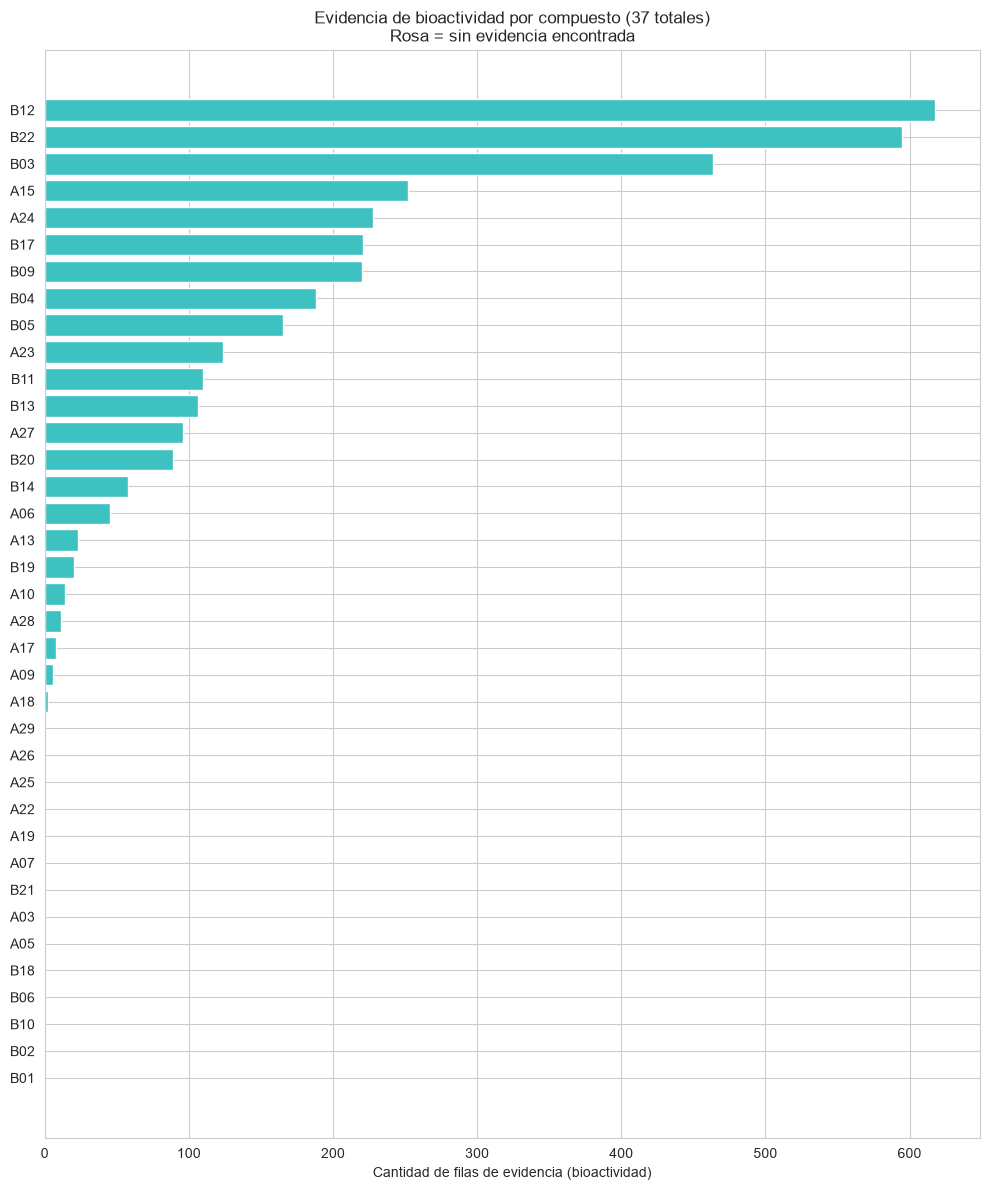

In [74]:
#CELDA II
conteo_evidencia = tabla_evidencia["Compound_ID"].value_counts()
todos_compuestos = compuestos_37.set_index("Compound_ID")[["Name"]].copy()
todos_compuestos["Total_filas"] = todos_compuestos.index.map(conteo_evidencia).fillna(0).astype(int)
todos_compuestos = todos_compuestos.sort_values("Total_filas")

fig, ax = plt.subplots(figsize=(10, 12))
colores = [PALETA_ROSA if v == 0 else PALETA_TEAL for v in todos_compuestos["Total_filas"]]
ax.barh(todos_compuestos.index, todos_compuestos["Total_filas"], color=colores)
ax.set_xlabel("Cantidad de filas de evidencia (bioactividad)")
ax.set_title("Evidencia de bioactividad por compuesto (37 totales)\nRosa = sin evidencia encontrada")
plt.tight_layout()
plt.savefig("../results/figures/paso2_evidencia_por_compuesto.png", dpi=150)
plt.show()

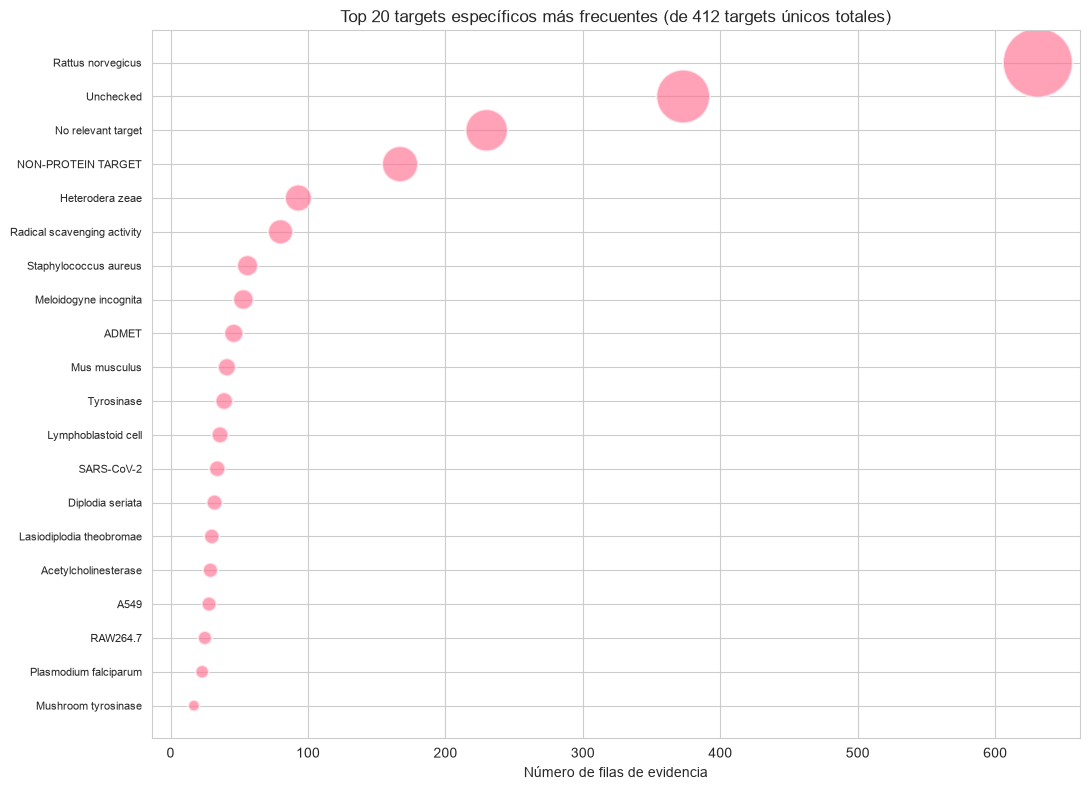

In [75]:
#CELDA JJ
top_targets = tabla_evidencia["Modelo_Detalle"].value_counts().head(20).sort_values()

fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(top_targets.values, range(len(top_targets)),
           s=top_targets.values * 4, alpha=0.65, color=PALETA_ROSA, edgecolors="white", linewidth=1.5)
ax.set_yticks(range(len(top_targets)))
ax.set_yticklabels(top_targets.index, fontsize=8)
ax.set_xlabel("Número de filas de evidencia")
ax.set_title("Top 20 targets específicos más frecuentes (de 412 targets únicos totales)")
plt.tight_layout()
plt.savefig("../results/figures/paso2_burbujas_target.png", dpi=150)
plt.show()

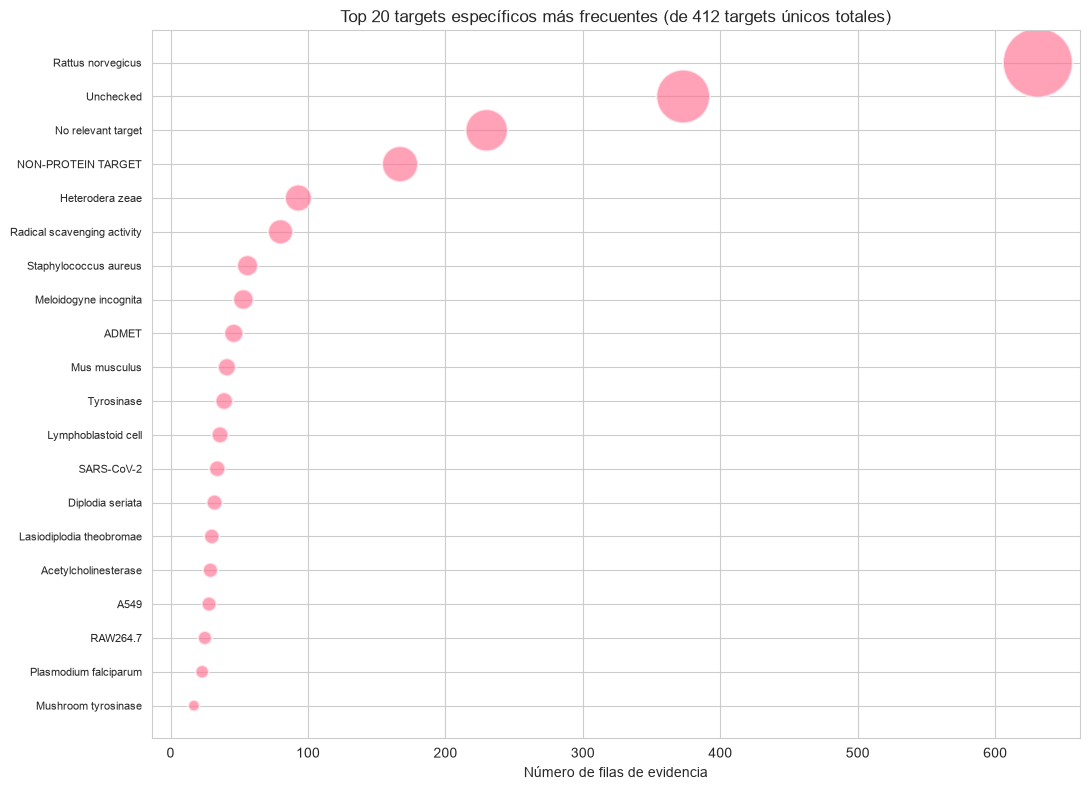

In [76]:
#CELDA KK
top_targets = tabla_evidencia["Modelo_Detalle"].value_counts().head(20).sort_values()

fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(top_targets.values, range(len(top_targets)),
           s=top_targets.values * 4, alpha=0.65, color=PALETA_ROSA, edgecolors="white", linewidth=1.5)
ax.set_yticks(range(len(top_targets)))
ax.set_yticklabels(top_targets.index, fontsize=8)
ax.set_xlabel("Número de filas de evidencia")
ax.set_title("Top 20 targets específicos más frecuentes (de 412 targets únicos totales)")
plt.tight_layout()
plt.savefig("../results/figures/paso2_burbujas_target.png", dpi=150)
plt.show()


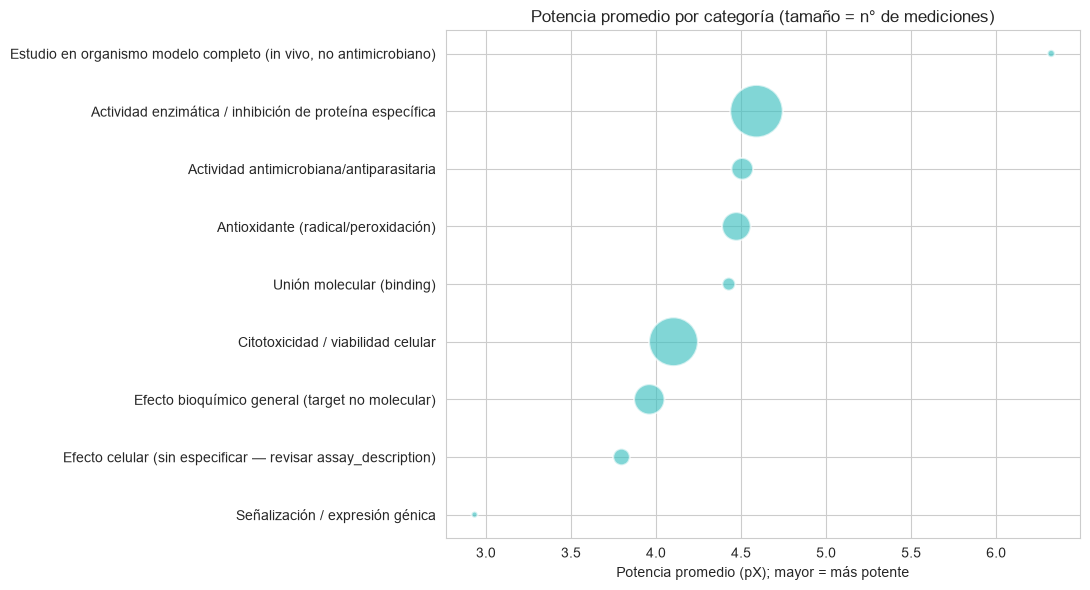

                                                                  pX_promedio  n_mediciones
Categoria_Endpoint                                                                         
Señalización / expresión génica                                      2.933109             5
Efecto celular (sin especificar — revisar assay_description)         3.797045            36
Efecto bioquímico general (target no molecular)                      3.960392           120
Citotoxicidad / viabilidad celular                                   4.102662           309
Unión molecular (binding)                                            4.427833            22
Antioxidante (radical/peroxidación)                                  4.472255           106
Actividad antimicrobiana/antiparasitaria                              4.50699            61
Actividad enzimática / inhibición de proteína específica             4.590564           357
Estudio en organismo modelo completo (in vivo, no antimicrobiano)     6.32295   

In [77]:
#CELDA LL
resumen_magnitud = tabla_evidencia[tabla_evidencia["Efecto_pX"].notna()].groupby("Categoria_Endpoint").agg(
    pX_promedio=("Efecto_pX", "mean"), n_mediciones=("Efecto_pX", "count")
).sort_values("pX_promedio")

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(resumen_magnitud["pX_promedio"], range(len(resumen_magnitud)),
           s=resumen_magnitud["n_mediciones"] * 4, alpha=0.65, color=PALETA_TEAL, edgecolors="white", linewidth=1.5)
ax.set_yticks(range(len(resumen_magnitud)))
ax.set_yticklabels(resumen_magnitud.index)
ax.set_xlabel("Potencia promedio (pX); mayor = más potente")
ax.set_title("Potencia promedio por categoría (tamaño = n° de mediciones)")
plt.tight_layout()
plt.savefig("../results/figures/paso2_burbujas_magnitud.png", dpi=150)
plt.show()
print(resumen_magnitud.to_string())

In [78]:
#CELDA QQ
def clasificar_origen(extract_str):
    if pd.isna(extract_str):
        return "Desconocido"
    tiene_em = "EM" in extract_str
    tiene_ev = "EV" in extract_str
    if tiene_em and tiene_ev:
        return "Ambos"
    elif tiene_em:
        return "Solo Melaza"
    elif tiene_ev:
        return "Solo Vinaza"
    return "Desconocido"

compuestos_37["Origen"] = compuestos_37["Extract"].apply(clasificar_origen)
print("Distribución de origen entre los 37 compuestos:")
print(compuestos_37["Origen"].value_counts())

tabla_con_origen = tabla_evidencia.merge(compuestos_37[["Compound_ID", "Origen"]], on="Compound_ID", how="left")

top_n = 6
categorias_top = tabla_con_origen["Categoria_Endpoint"].value_counts().head(top_n).index.tolist()
tabla_filtrada = tabla_con_origen[tabla_con_origen["Categoria_Endpoint"].isin(categorias_top)]

matriz_chord = pd.crosstab(tabla_filtrada["Origen"], tabla_filtrada["Categoria_Endpoint"])
orden_origen = [o for o in ["Solo Melaza", "Solo Vinaza", "Ambos"] if o in matriz_chord.index]
matriz_chord = matriz_chord.reindex(orden_origen, fill_value=0)
matriz_chord = matriz_chord.reindex(columns=categorias_top, fill_value=0)

print("\nMatriz Origen x Categoría (top 6 categorías):")
print(matriz_chord)

Distribución de origen entre los 37 compuestos:
Origen
Ambos          16
Solo Vinaza    12
Solo Melaza     9
Name: count, dtype: int64

Matriz Origen x Categoría (top 6 categorías):
Categoria_Endpoint  Actividad enzimática / inhibición de proteína específica  \
Origen                                                                         
Solo Melaza                                                       173          
Solo Vinaza                                                       264          
Ambos                                                             419          

Categoria_Endpoint  Estudio en organismo modelo completo (in vivo, no antimicrobiano)  \
Origen                                                                                  
Solo Melaza                                                       155                   
Solo Vinaza                                                       402                   
Ambos                                                        

In [ ]:
#CELDA RR
from matplotlib.patches import Wedge, Polygon

PALETA_ORIGEN = {"Solo Melaza": PALETA_ROSA, "Solo Vinaza": PALETA_TEAL, "Ambos": PALETA_AMBAR}

def punto_arco(radio, angulo_grados):
    a = np.radians(angulo_grados)
    return radio * np.cos(a), radio * np.sin(a)

def curva_bezier(p0, p1, n=30):
    t = np.linspace(0, 1, n)
    x = (1-t)**2 * p0[0] + t**2 * p1[0]
    y = (1-t)**2 * p0[1] + t**2 * p1[1]
    return list(zip(x, y))

def texto_legible(ax, angulo_grados, radio, texto, **kwargs):
    a = angulo_grados % 360
    x, y = radio*np.cos(np.radians(a)), radio*np.sin(np.radians(a))
    if 90 < a < 270:
        rotacion, ha = a + 180, "right"
    else:
        rotacion, ha = a, "left"
    ax.text(x, y, texto, rotation=rotacion, ha=ha, va="center", rotation_mode="anchor", **kwargs)

def dibujar_chord_diagram(matriz, titulo=""):
    nombres_origen = matriz.index.tolist()
    nombres_categoria = matriz.columns.tolist()
    valores = matriz.values.astype(float)
    n_origen, n_categoria = len(nombres_origen), len(nombres_categoria)
    total_origen, total_categoria = valores.sum(axis=1), valores.sum(axis=0)
    total_general = valores.sum()

    gap, buffer_transicion = 4, 25
    grados_disponibles = 360 - gap * (n_origen + n_categoria) - buffer_transicion * 2
    escala = grados_disponibles / total_general

    fig, ax = plt.subplots(figsize=(11, 11))

    angulo_actual = 90 + buffer_transicion / 2
    posiciones_origen = []
    for total in total_origen:
        ancho = total * escala
        posiciones_origen.append((angulo_actual, angulo_actual + ancho))
        angulo_actual += ancho + gap
    angulo_actual += buffer_transicion
    posiciones_categoria = []
    for total in total_categoria:
        ancho = total * escala
        posiciones_categoria.append((angulo_actual, angulo_actual + ancho))
        angulo_actual += ancho + gap

    radio_interior = 0.90

    for i, (a0, a1) in enumerate(posiciones_origen):
        color = PALETA_ORIGEN.get(nombres_origen[i], "#999999")
        ax.add_patch(Wedge((0,0), 1.0, a0, a1, width=0.08, facecolor=color, edgecolor="white"))
        ancho_total = a1 - a0
        angulo_etiqueta = a0 + min(ancho_total/2, 12) if ancho_total > 40 else (a0+a1)/2
        texto_legible(ax, angulo_etiqueta, 1.38, nombres_origen[i], fontsize=12, fontweight="bold")
    for j, (a0, a1) in enumerate(posiciones_categoria):
        ax.add_patch(Wedge((0,0), 1.0, a0, a1, width=0.08, facecolor="#D9D9D9", edgecolor="white"))
        texto_legible(ax, (a0+a1)/2, 1.08, nombres_categoria[j], fontsize=9.5)

    cursor_origen = [p[0] for p in posiciones_origen]
    cursor_categoria = [p[0] for p in posiciones_categoria]
    conexiones = [(i, j, valores[i, j]) for i in range(n_origen) for j in range(n_categoria) if valores[i, j] > 0]
    conexiones.sort(key=lambda x: -x[2])

    for i, j, peso in conexiones:
        ancho = peso * escala
        a0o, a1o = cursor_origen[i], cursor_origen[i] + ancho
        cursor_origen[i] = a1o
        a0c, a1c = cursor_categoria[j], cursor_categoria[j] + ancho
        cursor_categoria[j] = a1c
        p0a, p0b = punto_arco(radio_interior, a0o), punto_arco(radio_interior, a1o)
        p1a, p1b = punto_arco(radio_interior, a1c), punto_arco(radio_interior, a0c)
        verts = [p0a] + curva_bezier(p0b, p1a) + [p1a] + curva_bezier(p1b, p0a)
        color = PALETA_ORIGEN.get(nombres_origen[i], "#999999")
        ax.add_patch(Polygon(verts, closed=True, facecolor=color, edgecolor="none", alpha=0.35))

    ax.set_xlim(-1.75, 1.75); ax.set_ylim(-1.75, 1.75)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(titulo, fontsize=14, pad=20)
    plt.tight_layout()
    return fig

print("✅ Función de chord diagram definida")

✅ Función de chord diagram definida


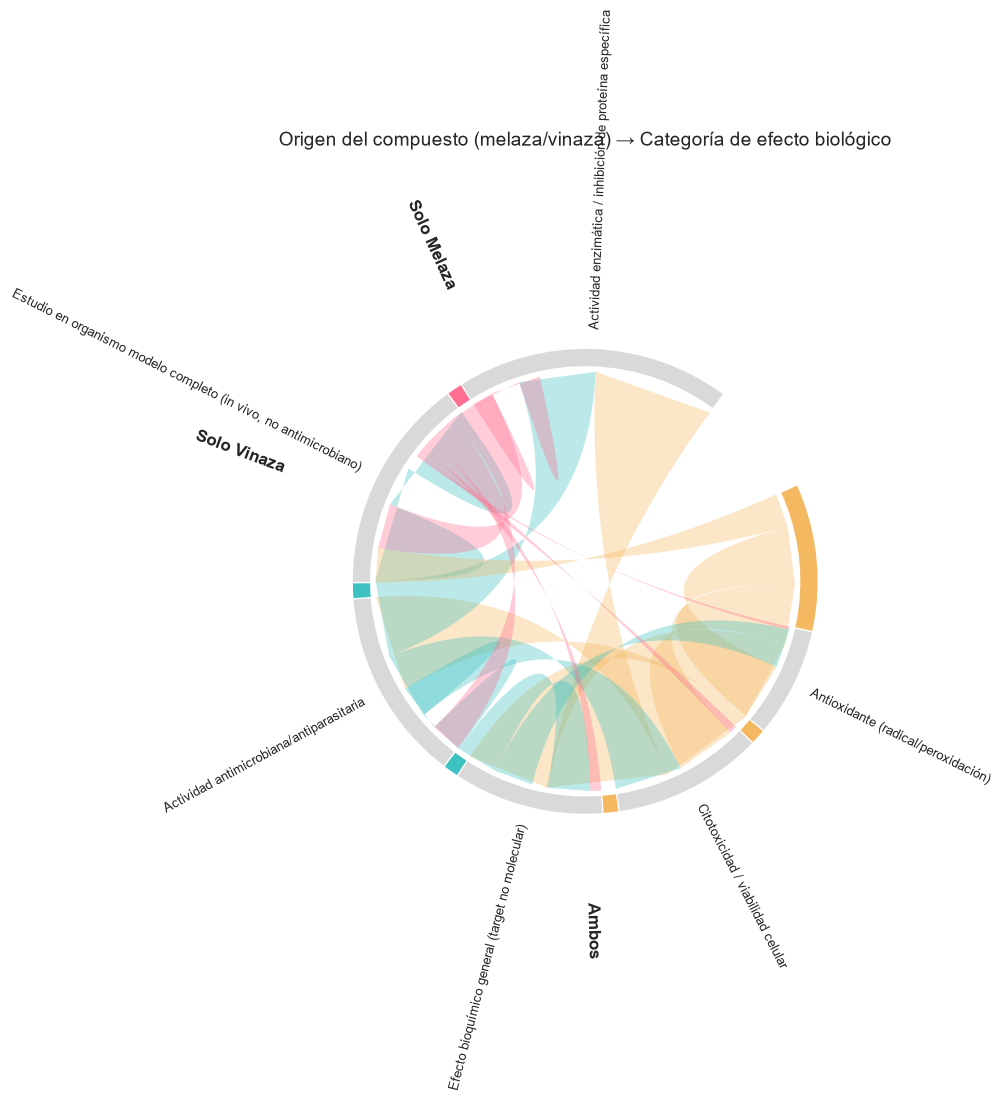

In [ ]:
#CELDA SS
fig = dibujar_chord_diagram(matriz_chord, "Origen del compuesto (melaza/vinaza) → Categoría de efecto biológico")
fig.savefig("../results/figures/paso2_chord_origen.png", dpi=150)
plt.show()

C:\Users\jpenafiel\AppData\Local\Temp\ipykernel_17104\2584390190.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


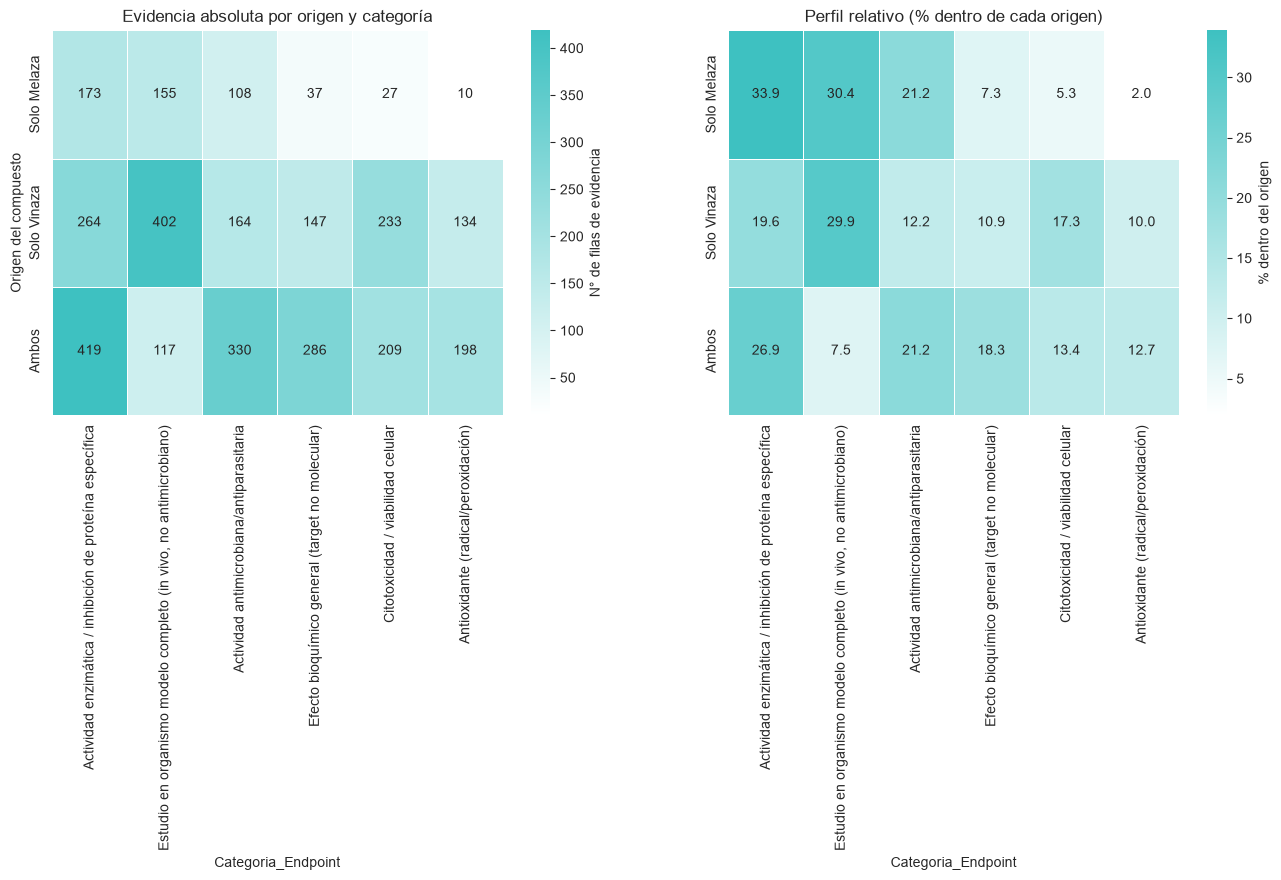

In [82]:
#celda UU
import matplotlib.colors as mcolors

cmap_teal = mcolors.LinearSegmentedColormap.from_list("blanco_teal", ["#FFFFFF", PALETA_TEAL])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(matriz_chord, annot=True, fmt="d", cmap=cmap_teal,
            cbar_kws={"label": "N° de filas de evidencia"}, linewidths=0.5, linecolor="white", ax=axes[0])
axes[0].set_title("Evidencia absoluta por origen y categoría")
axes[0].set_ylabel("Origen del compuesto")

matriz_normalizada = matriz_chord.div(matriz_chord.sum(axis=1), axis=0) * 100
sns.heatmap(matriz_normalizada, annot=True, fmt=".1f", cmap=cmap_teal,
            cbar_kws={"label": "% dentro del origen"}, linewidths=0.5, linecolor="white", ax=axes[1])
axes[1].set_title("Perfil relativo (% dentro de cada origen)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("../results/figures/paso2_heatmap_origen.png", dpi=150)
plt.show()

In [83]:
#celda TT
resumen_origen = pd.DataFrame({
    "Total_evidencia": matriz_chord.sum(axis=1),
    "N_compuestos": compuestos_37["Origen"].value_counts()
})
resumen_origen["Evidencia_promedio_por_compuesto"] = (
    resumen_origen["Total_evidencia"] / resumen_origen["N_compuestos"]
).round(1)

print(resumen_origen.to_string())

             Total_evidencia  N_compuestos  Evidencia_promedio_por_compuesto
Origen                                                                      
Ambos                   1559            16                              97.4
Solo Melaza              510             9                              56.7
Solo Vinaza             1344            12                             112.0
